<a href="https://colab.research.google.com/github/sadikajannat/stunting-eda/blob/main/now_final_file.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn as sb
import os
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd
import numpy as np
from scipy.stats import shapiro
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import numpy as np
import random

np.random.seed(42)
random.seed(42)

In [ ]:

df = pd.read_excel("/content/bdhs2022_final_analysis_dataset.xlsx")



In [ ]:
df.head()

,age_months,sample_weight,cluster_id,hh_id,child_line,wealth_index,mother_edu,place_delivery,toilet_type,father_occ,...,assist_aux_midwife,assist_trad_birth,assist_other,wt,mother_bmi,wealth_3cat,mother_edu_bin,medical_assist,stunted,haz
0,46.0,156207,1.0,43.0,1,5,2,NaN,11,0.0,...,NaN,NaN,NaN,0.156207,248.8,rich,1,0,0,1.15
1,46.0,156207,1.0,85.0,1,3,2,NaN,12,NaN,...,NaN,NaN,NaN,0.156207,290.6,middle,1,0,0,-0.34
2,49.0,156207,1.0,102.0,1,5,3,NaN,12,1.0,...,NaN,NaN,NaN,0.156207,252.9,rich,1,0,0,-0.22
3,32.0,156207,1.0,111.0,1,4,3,23.0,13,0.0,...,0.0,0.0,0.0,0.156207,217.0,rich,1,1,0,0.08
4,18.0,141953,2.0,3.0,1,4,2,32.0,14,3.0,...,0.0,0.0,0.0,0.141953,265.4,rich,1,1,0,-1.61


In [ ]:
df.tail()

,age_months,sample_weight,cluster_id,hh_id,child_line,wealth_index,mother_edu,place_delivery,toilet_type,father_occ,...,assist_aux_midwife,assist_trad_birth,assist_other,wt,mother_bmi,wealth_3cat,mother_edu_bin,medical_assist,stunted,haz
4100,2.0,699635,675.0,70.0,1,1,1,32.0,22,7.0,...,0.0,0.0,0.0,0.699635,231.2,poor,0,1,0,-0.47
4101,28.0,699635,675.0,70.0,2,1,1,11.0,22,7.0,...,0.0,0.0,0.0,0.699635,231.2,poor,0,0,0,-1.79
4102,39.0,699635,675.0,108.0,1,2,2,NaN,23,7.0,...,NaN,NaN,NaN,0.699635,232.1,poor,1,0,0,-1.44
4103,12.0,699635,675.0,108.0,1,2,2,11.0,23,NaN,...,0.0,0.0,0.0,0.699635,248.8,poor,1,0,0,-1.00
4104,46.0,699635,675.0,108.0,2,2,2,NaN,23,NaN,...,NaN,NaN,NaN,0.699635,248.8,poor,1,0,1,-2.27


In [ ]:
df.shape

(4105, 35)

In [ ]:
print(df.columns.tolist())

['age_months', 'sample_weight', 'cluster_id', 'hh_id', 'child_line', 'wealth_index', 'mother_edu', 'place_delivery', 'toilet_type', 'father_occ', 'mother_bmi_x10', 'birth_order', 'has_tv', 'mother_occ', 'birth_interval_months', 'children_ever_born', 'father_edu', 'size_at_birth', 'desire_more_children', 'division', 'mother_age', 'reads_newspaper', 'has_electricity', 'assist_doctor', 'assist_nurse_midwife', 'assist_aux_midwife', 'assist_trad_birth', 'assist_other', 'wt', 'mother_bmi', 'wealth_3cat', 'mother_edu_bin', 'medical_assist', 'stunted', 'haz']


 missing value check  
# heatmap

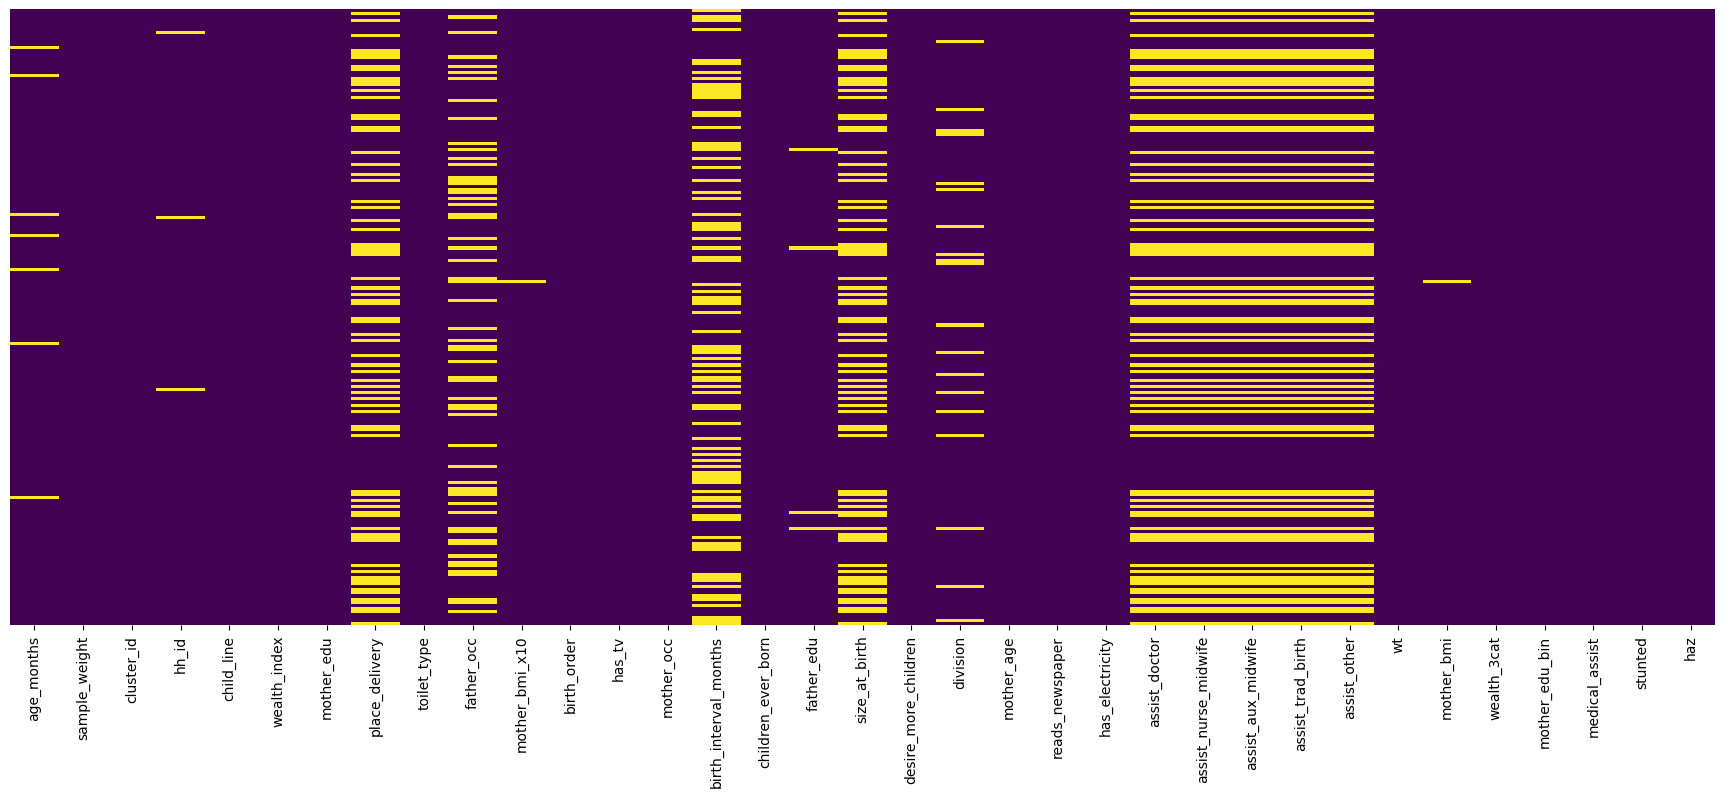

In [ ]:
plt.figure(figsize=(22, 8))
sns.heatmap(
  df.sample(200).isnull(),  # sample rows
    yticklabels=False,
    cbar=False,
    cmap='viridis'
)
plt.show()


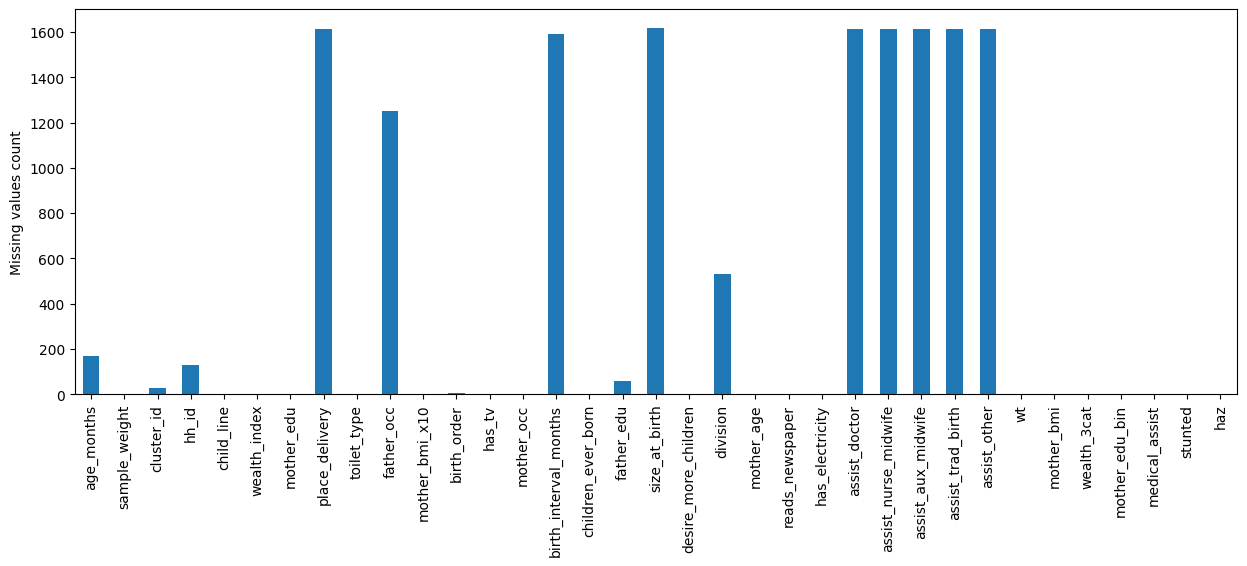

In [ ]:
df.isnull().sum().plot(kind='bar', figsize=(15,5))
plt.ylabel("Missing values count")
plt.show() # bar chart


In [ ]:
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Variable': missing_percent.index,
    'Missing_Percent': missing_percent.values
}).sort_values(by='Missing_Percent', ascending=False)

print(missing_df)

                 Variable  Missing_Percent
17          size_at_birth        39.464068
7          place_delivery        39.317905
25     assist_aux_midwife        39.317905
23          assist_doctor        39.317905
24   assist_nurse_midwife        39.317905
26      assist_trad_birth        39.317905
27           assist_other        39.317905
14  birth_interval_months        38.781973
9              father_occ        30.523752
19               division        12.984166
0              age_months         4.092570
3                   hh_id         3.166870
16             father_edu         1.437272
2              cluster_id         0.682095
11            birth_order         0.097442
15     children_ever_born         0.073082
10         mother_bmi_x10         0.048721
29             mother_bmi         0.048721
1           sample_weight         0.000000
18   desire_more_children         0.000000
13             mother_occ         0.000000
12                 has_tv         0.000000
8          

In [ ]:
df.columns = df.columns.str.strip()

In [ ]:
df = df.drop(columns=['hh_id', 'cluster_id', 'sample_weight', 'mother_bmi_x10'])

In [ ]:
df.shape

(4105, 31)

In [ ]:
missing_percent = df.isnull().mean() * 100

In [ ]:
threshold = 30


In [ ]:
df = df.loc[:, missing_percent <= threshold]


In [ ]:
cols_to_drop = missing_percent[missing_percent > 30].index
print(cols_to_drop)


Index(['place_delivery', 'father_occ', 'birth_interval_months',
       'size_at_birth', 'assist_doctor', 'assist_nurse_midwife',
       'assist_aux_midwife', 'assist_trad_birth', 'assist_other'],
      dtype='object')


In [ ]:
df.shape

(4105, 22)

In [ ]:
# Select numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
numeric_cols


Index(['age_months', 'child_line', 'wealth_index', 'mother_edu', 'toilet_type',
       'birth_order', 'has_tv', 'mother_occ', 'children_ever_born',
       'father_edu', 'desire_more_children', 'division', 'mother_age',
       'reads_newspaper', 'has_electricity', 'wt', 'mother_bmi',
       'mother_edu_bin', 'medical_assist', 'stunted', 'haz'],
      dtype='object')

In [ ]:
id_vars = [ 'child_line']


In [ ]:
numeric_vars = [
 'age_months',


 'children_ever_born',
 'mother_age',
 'wt',
 'mother_bmi',
 'haz'
]


In [ ]:
all_df_cols = df.columns.tolist()

# Filter id_vars to only include columns that are still in df
current_id_vars = [col for col in id_vars if col in all_df_cols]

# Filter numeric_vars to only include columns that are still in df
current_numeric_vars = [col for col in numeric_vars if col in all_df_cols]

categorical_vars = list(
    set(all_df_cols) - set(current_id_vars) - set(current_numeric_vars)
)



In [ ]:
print("ID variables:\n", id_vars)
print("\nNumeric variables:\n", numeric_vars)
print("\nCategorical variables:\n", categorical_vars)


ID variables:
 ['child_line']

Numeric variables:
 ['age_months', 'children_ever_born', 'mother_age', 'wt', 'mother_bmi', 'haz']

Categorical variables:
 ['mother_edu', 'has_electricity', 'father_edu', 'toilet_type', 'medical_assist', 'reads_newspaper', 'birth_order', 'mother_occ', 'stunted', 'has_tv', 'desire_more_children', 'division', 'wealth_index', 'wealth_3cat', 'mother_edu_bin']


# Normality check

In [ ]:


# Numeric (continuous) variables from our dataset
numeric_vars = [
    'age_months',


    'children_ever_born',
    'mother_age',
    'wt',
    'mother_bmi',

]

normality_results = []

for col in numeric_vars:
    data = df[col].dropna()

    # Skip very small samples
    if len(data) < 10:
        continue

    skewness = data.skew()

    # Shapiro test (sample if dataset is large)
    stat, p_value = shapiro(data.sample(500) if len(data) > 500 else data)

    normality_results.append({
        "Variable": col,
        "Skewness": round(skewness, 3),
        "Shapiro_p_value": round(p_value, 4),
        "Distribution": "Normal" if p_value > 0.05 else "Non-normal"
    })

# Create normality table
normality_table = pd.DataFrame(normality_results)

normality_table


,Variable,Skewness,Shapiro_p_value,Distribution
0,age_months,-0.046,0.0,Non-normal
1,children_ever_born,1.286,0.0,Non-normal
2,mother_age,0.507,0.0,Non-normal
3,wt,1.009,0.0,Non-normal
4,mother_bmi,0.643,0.0,Non-normal


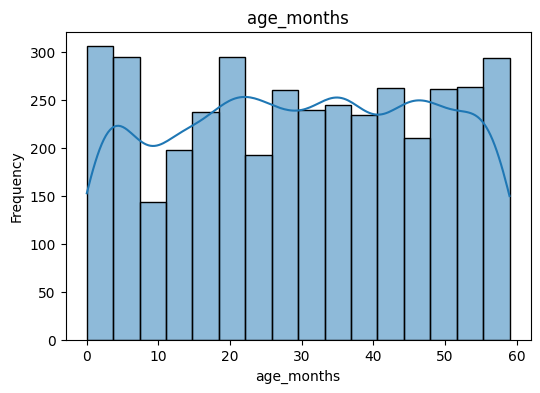

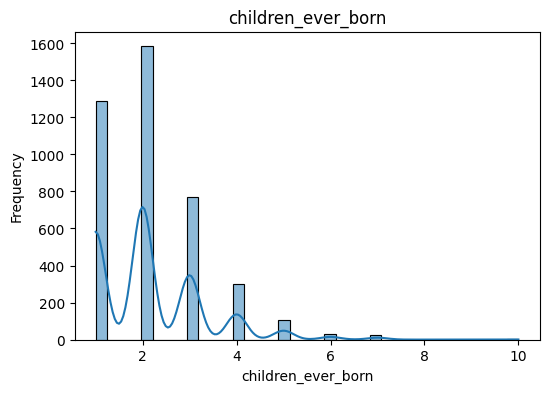

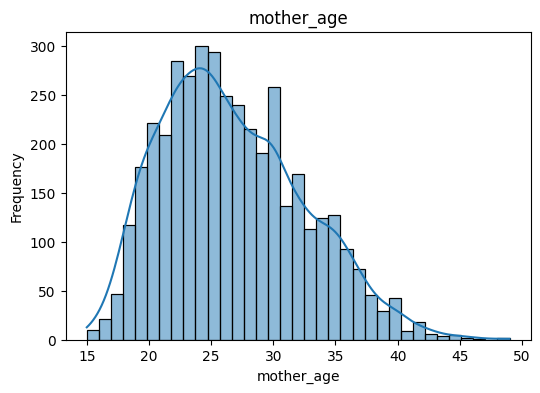

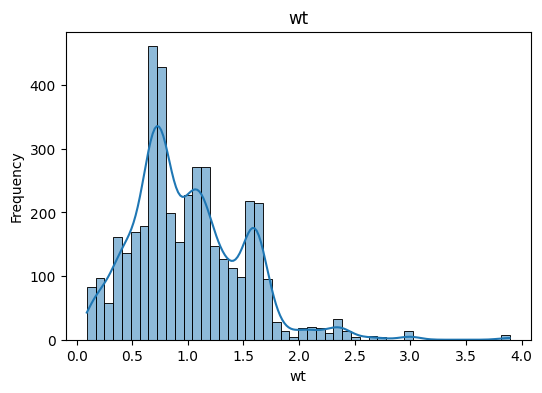

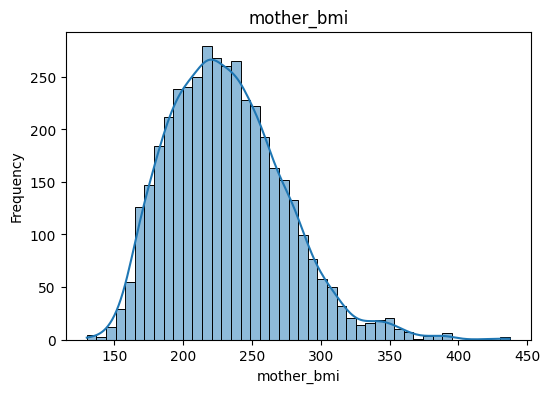

In [ ]:


# List of numeric variables (non-normal)
numeric_cols = [
    'age_months',


    'children_ever_born',
    'mother_age',
    'wt',
    'mother_bmi',

]

# Plot each variable individually
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)   # pass only one column at a time
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


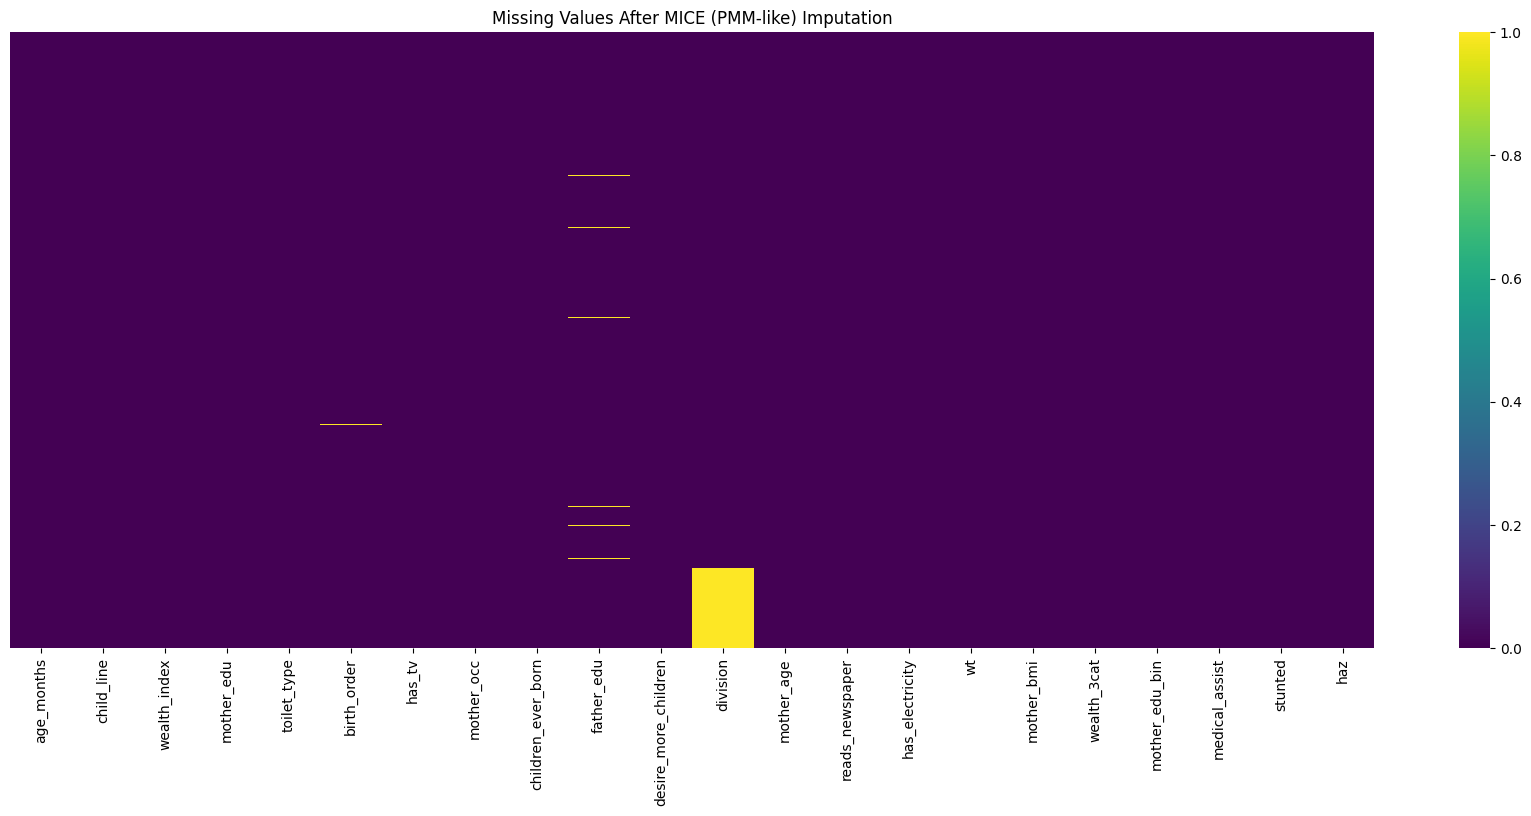

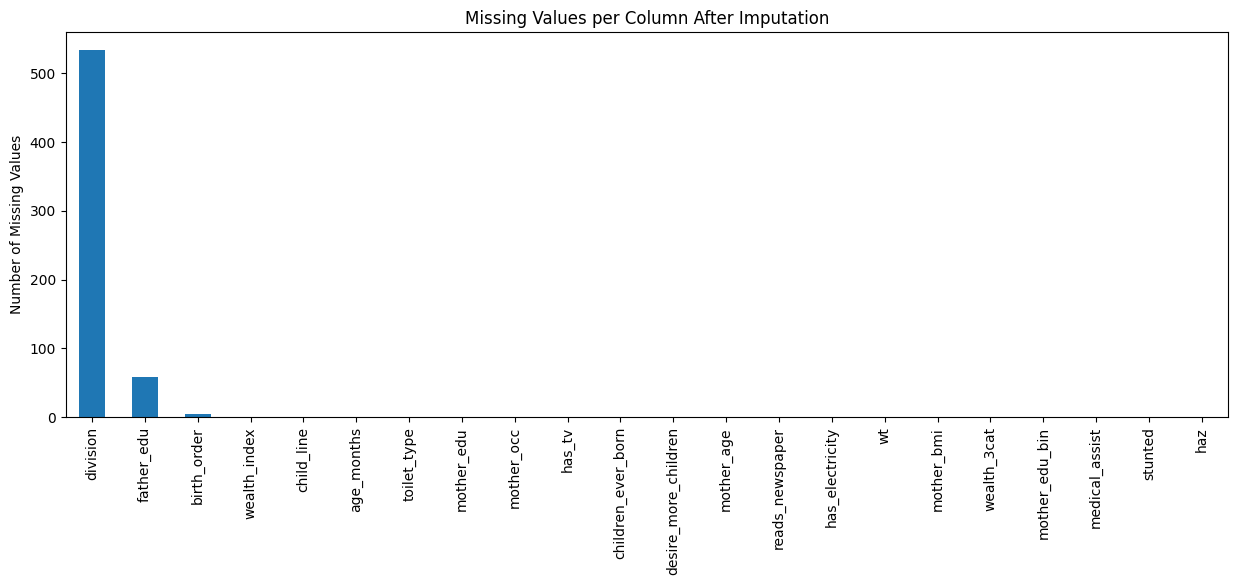

Total missing values after imputation: 596


In [ ]:

# =============================
# Imports (Colab compatible)
# =============================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge

# =============================
# Load data (example)
# =============================
# from google.colab import files
# uploaded = files.upload()
# df = pd.read_csv(list(uploaded.keys())[0])

# =============================
# Define NON-NORMAL variables
# =============================
non_normal_vars = [  'age_months',


    'children_ever_born',
    'mother_age',
    'wt',
    'mother_bmi',
    'haz']  # replace with yours

# =============================
# MICE / PMM-like Imputation
# =============================
mice_imputer = IterativeImputer(
    estimator=BayesianRidge(),
    max_iter=10,
    random_state=42,
    sample_posterior=True
)

df[non_normal_vars] = mice_imputer.fit_transform(df[non_normal_vars])

# =============================
# Check missing values
# =============================
plt.figure(figsize=(22, 8))
sns.heatmap(df.isnull(), yticklabels=False, cbar=True, cmap='viridis')
plt.title("Missing Values After MICE (PMM-like) Imputation")
plt.show()

df.isnull().sum().sort_values(ascending=False).plot(
    kind='bar', figsize=(15, 5)
)
plt.ylabel("Number of Missing Values")
plt.title("Missing Values per Column After Imputation")
plt.show()

print("Total missing values after imputation:", df.isnull().sum().sum())




In [ ]:
import pandas as pd

missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Variable': missing_percent.index,
    'Missing_Percent': missing_percent.values
}).sort_values(by='Missing_Percent', ascending=False)

print(missing_df)



                Variable  Missing_Percent
11              division        12.984166
9             father_edu         1.437272
5            birth_order         0.097442
2           wealth_index         0.000000
1             child_line         0.000000
0             age_months         0.000000
4            toilet_type         0.000000
3             mother_edu         0.000000
7             mother_occ         0.000000
6                 has_tv         0.000000
8     children_ever_born         0.000000
10  desire_more_children         0.000000
12            mother_age         0.000000
13       reads_newspaper         0.000000
14       has_electricity         0.000000
15                    wt         0.000000
16            mother_bmi         0.000000
17           wealth_3cat         0.000000
18        mother_edu_bin         0.000000
19        medical_assist         0.000000
20               stunted         0.000000
21                   haz         0.000000


In [ ]:
cat_vars = ['division', 'father_edu', 'birth_order']


In [ ]:
for col in cat_vars:
    df[col] = df[col].fillna(df[col].mode()[0])


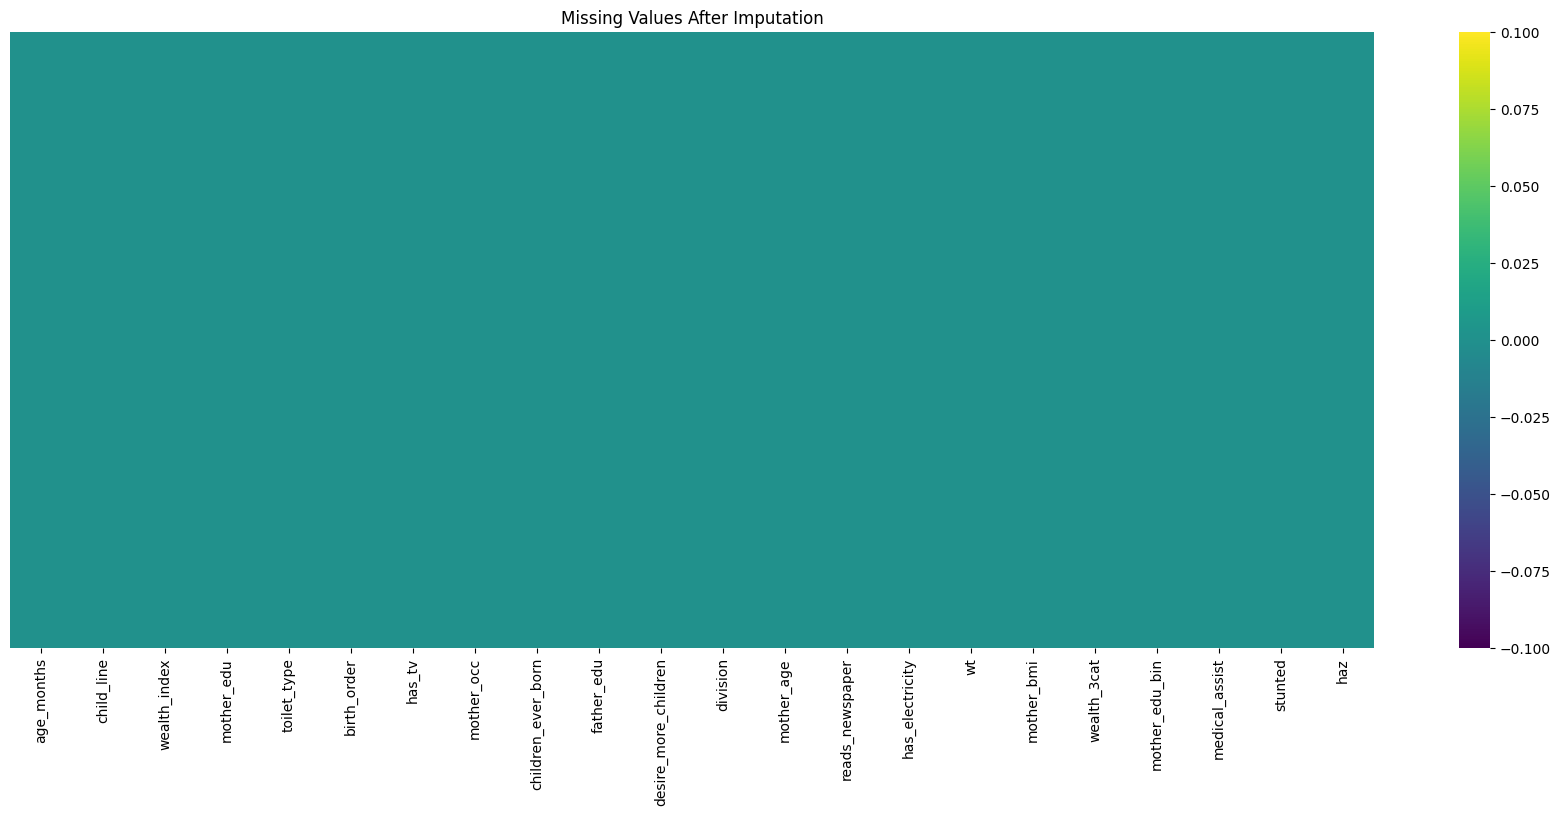

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(22,8))  # make it wide enough for all columns
sns.heatmap(df.isnull(),
            yticklabels=False,
            cbar=True,
            cmap='viridis')

plt.title("Missing Values After Imputation")
plt.show()


aftre missing value handled we have 24 variable

In [ ]:
df.shape

(4105, 22)

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age_months,4105.0,29.875616,17.510514,-9.093091,15.000000,30.000000,45.000000,76.611535
child_line,4105.0,1.115469,0.333066,1.000000,1.000000,1.000000,1.000000,4.000000
wealth_index,4105.0,2.955664,1.423310,1.000000,2.000000,3.000000,4.000000,5.000000
mother_edu,4105.0,1.837028,0.798386,0.000000,1.000000,2.000000,2.000000,3.000000
toilet_type,4105.0,26.696224,23.960241,11.000000,13.000000,21.000000,23.000000,97.000000
birth_order,4105.0,2.041169,1.107968,1.000000,1.000000,2.000000,3.000000,7.000000
has_tv,4105.0,1.136663,1.999898,0.000000,0.000000,1.000000,1.000000,7.000000
mother_occ,4105.0,0.242387,0.428580,0.000000,0.000000,0.000000,0.000000,1.000000
children_ever_born,4105.0,2.160477,1.133056,1.000000,1.000000,2.000000,3.000000,10.000000
father_edu,4105.0,1.592205,0.966464,0.000000,1.000000,2.000000,2.000000,3.000000


In [ ]:
# Ensure lists match existing columns
numeric_vars = [col for col in numeric_vars if col in df.columns]
categorical_vars = [col for col in categorical_vars if col in df.columns]

# Convert numeric-coded categorical variables to 'category' type
for col in categorical_vars:
    df[col] = df[col].astype('category')

# Now describe
print(df[numeric_vars].describe())
print(df[categorical_vars].describe())


        age_months  children_ever_born   mother_age           wt   mother_bmi
count  4105.000000         4105.000000  4105.000000  4105.000000  4105.000000
mean     29.875616            2.160477    26.685262     0.999883   231.555501
std      17.510514            1.133056     5.735380     0.504050    42.010665
min      -9.093091            1.000000    15.000000     0.091325   130.000000
25%      15.000000            1.000000    22.000000     0.661481   200.300000
50%      30.000000            2.000000    26.000000     0.917131   228.000000
75%      45.000000            3.000000    30.000000     1.304506   257.300000
max      76.611535           10.000000    49.000000     3.891736   437.100000
        mother_edu  has_electricity  father_edu  toilet_type  medical_assist  \
count         4105             4105      4105.0         4105            4105   
unique           4                3         4.0           13               2   
top              2                1         2.0           

### **Univariate Analysis (1st numerical 2nd categorical)**
# histplot to understand  the distribution
variable    valuemeaning

 has_electricity           {0: 'no', 1: 'yes', 7: 'not a dejure resident'}



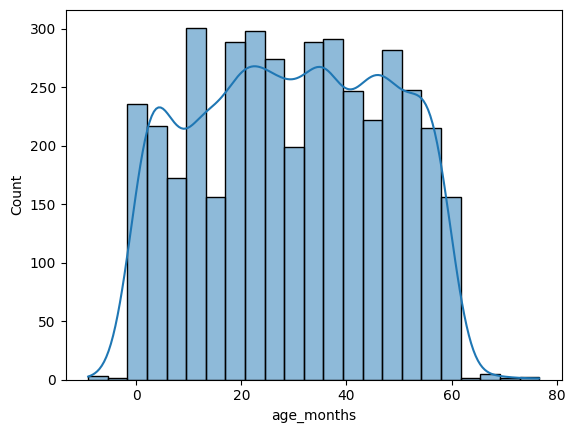

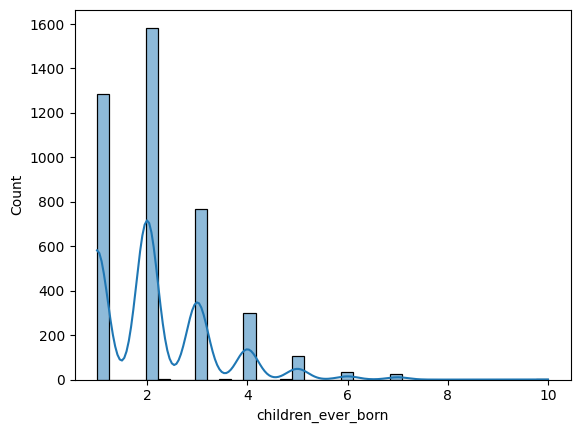

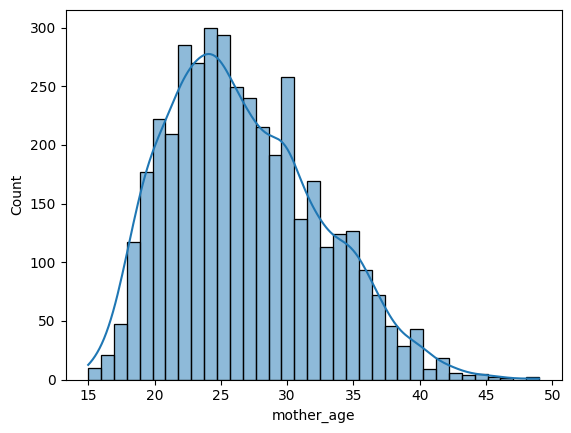

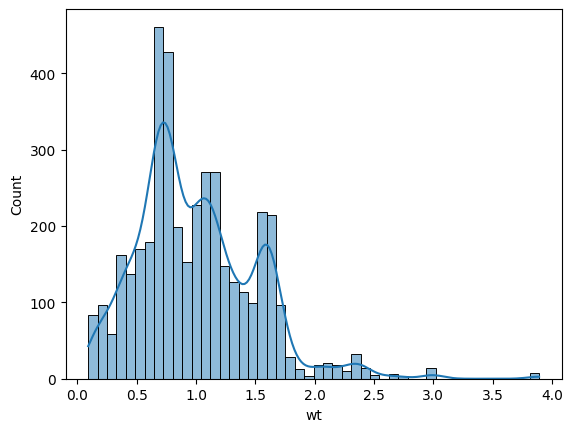

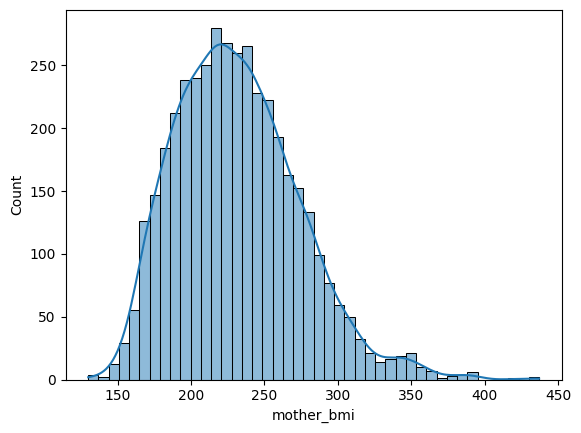

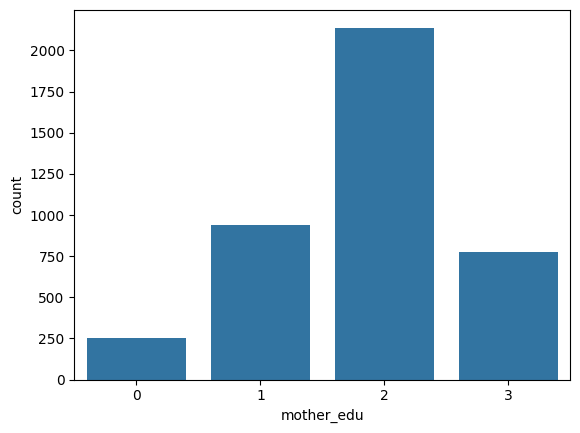

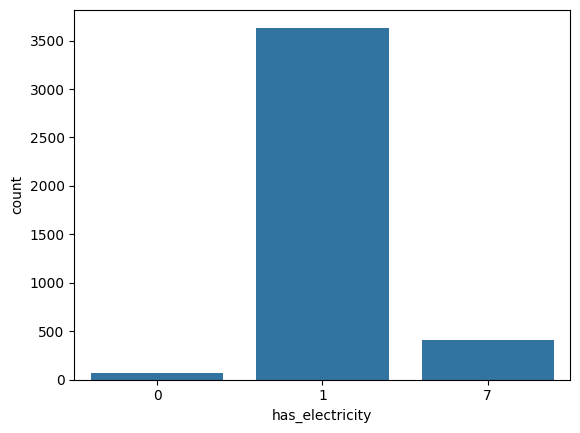

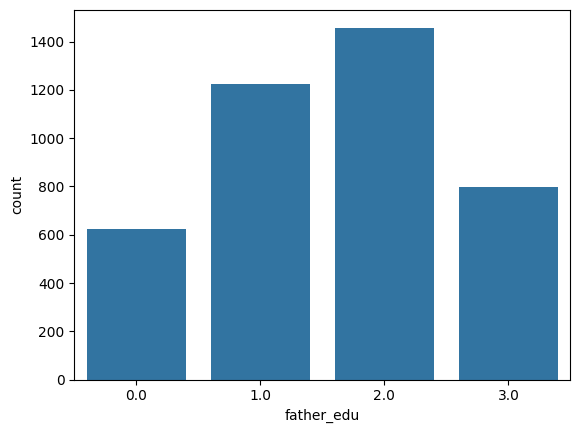

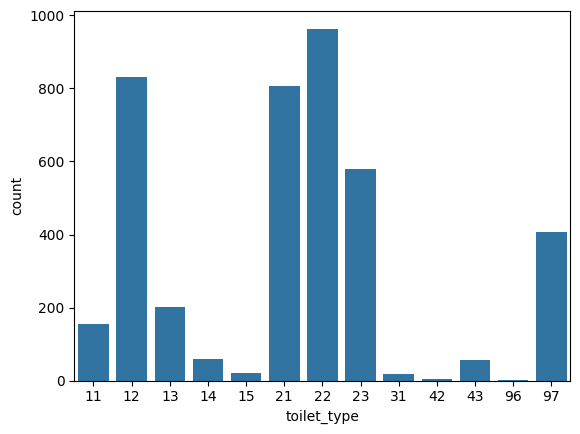

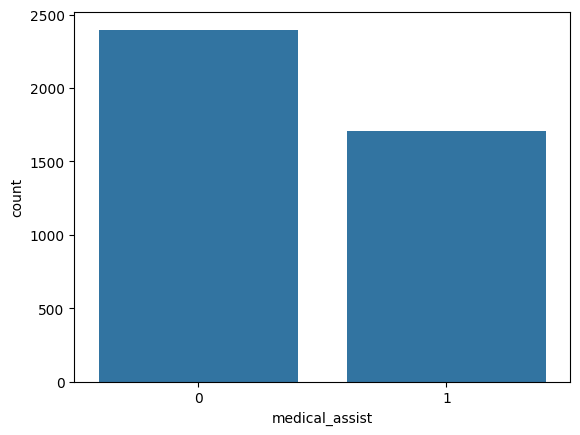

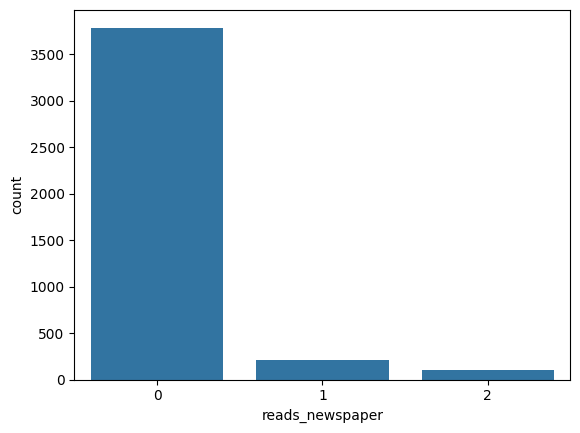

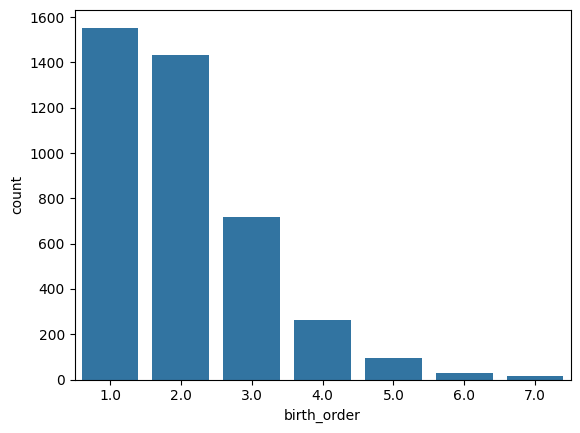

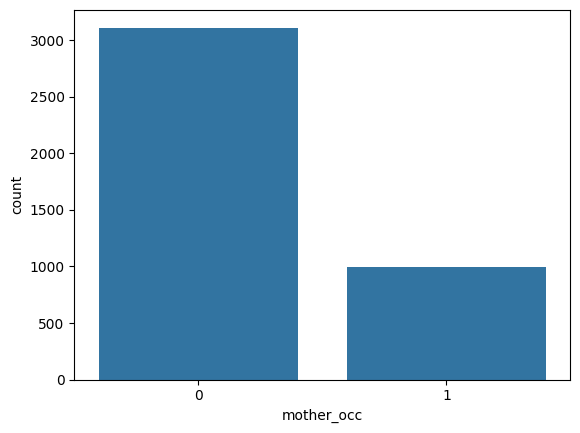

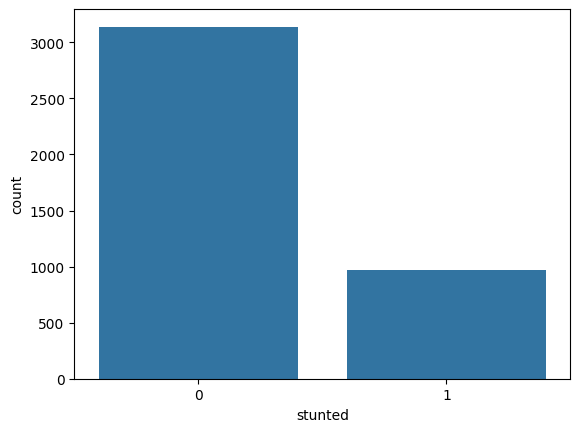

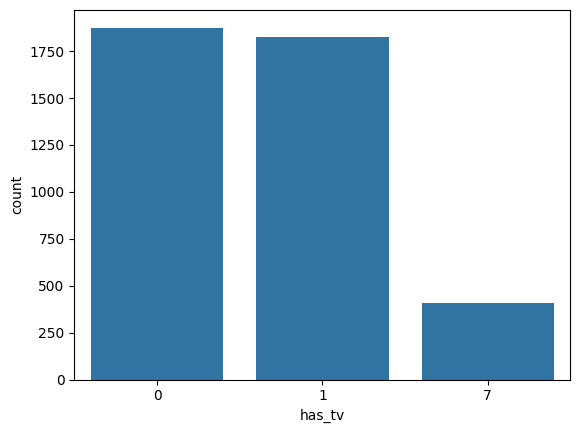

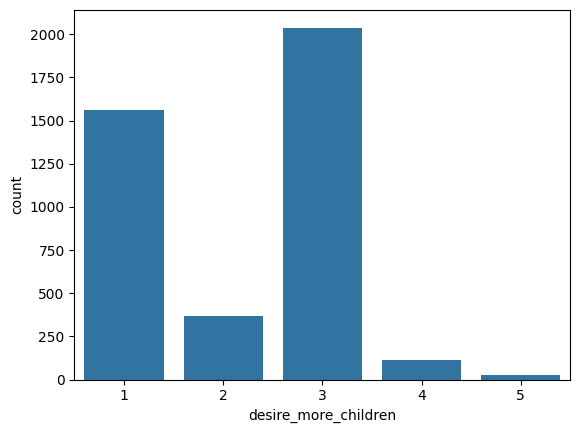

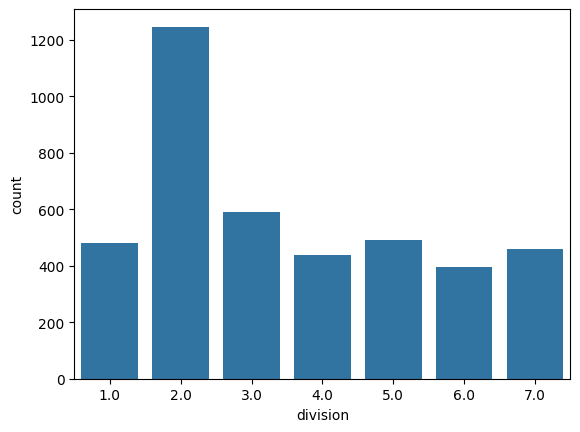

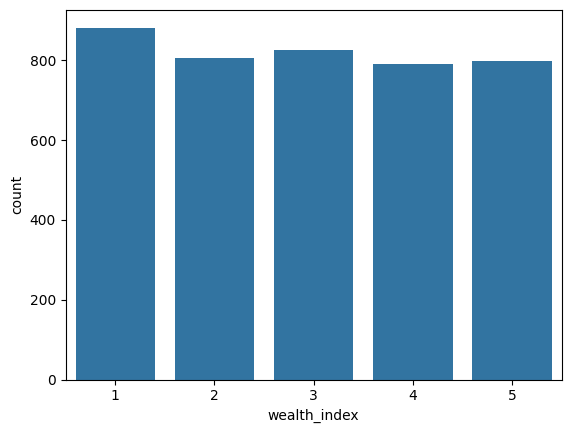

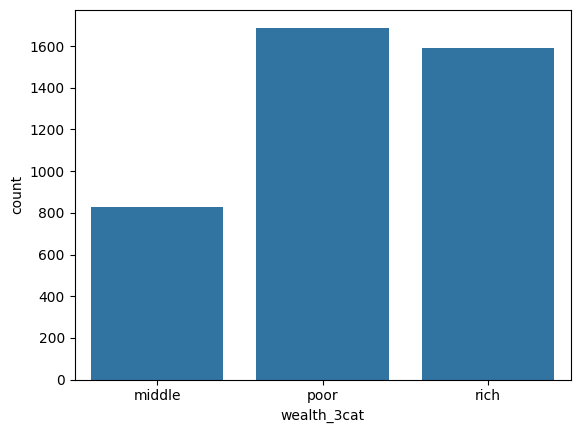

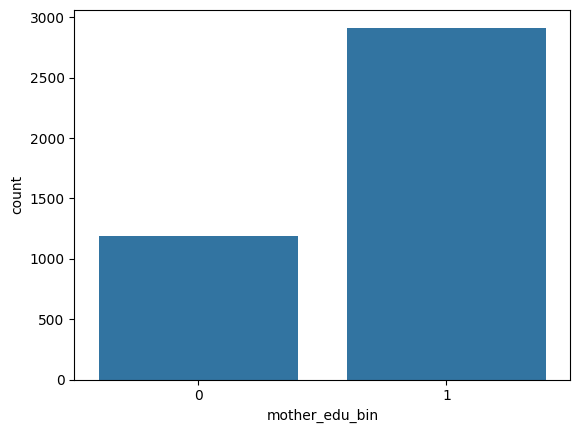

In [ ]:


# Numeric
for col in numeric_vars:
    sns.histplot(df[col], kde=True)
    plt.show()

# Categorical
for col in categorical_vars:
    sns.countplot(x=df[col])
    plt.show()


#boxplot to identify the outlier

In [ ]:
def iqr_outliers(df, columns):
    outlier_info = {}

    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lb = Q1 - 1.5 * IQR
        ub = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lb) | (df[col] > ub)]

        outlier_info[col] = {
            "lower_bound": lb,
            "upper_bound": ub,
            "num_outliers": outliers.shape[0]
        }

    return outlier_info


In [ ]:
columns_to_check = [
    'age_months',
    'mother_bmi',

    'mother_age',


    'wt'
]

outlier_results = iqr_outliers(df, columns_to_check)


In [ ]:
for col, stats in outlier_results.items():
    print(f"\nColumn: {col}")
    print("Lower bound:", stats["lower_bound"])
    print("Upper bound:", stats["upper_bound"])
    print("Number of outliers:", stats["num_outliers"])



Column: age_months
Lower bound: -30.0
Upper bound: 90.0
Number of outliers: 0

Column: mother_bmi
Lower bound: 114.80000000000001
Upper bound: 342.8
Number of outliers: 59

Column: mother_age
Lower bound: 10.0
Upper bound: 42.0
Number of outliers: 20

Column: wt
Lower bound: -0.30305649999999995
Upper bound: 2.2690435
Number of outliers: 93


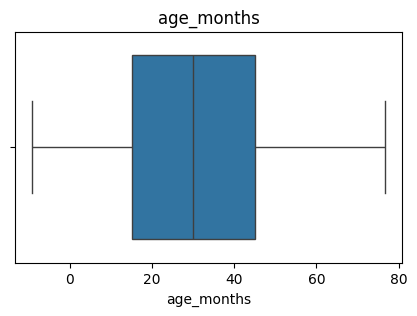

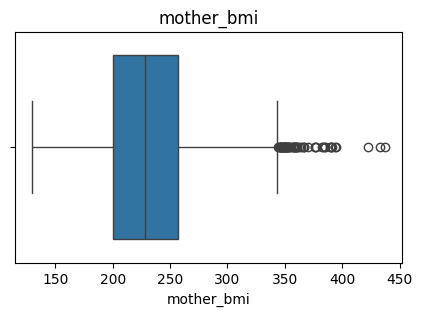

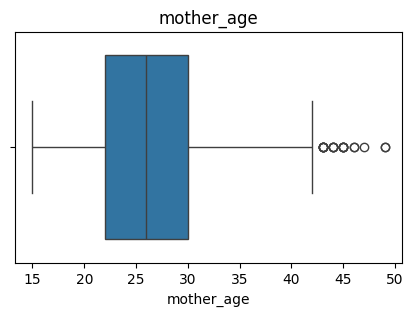

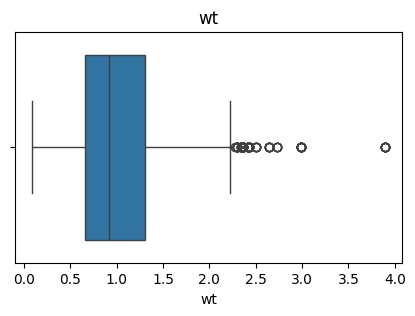

In [ ]:
for col in columns_to_check:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()


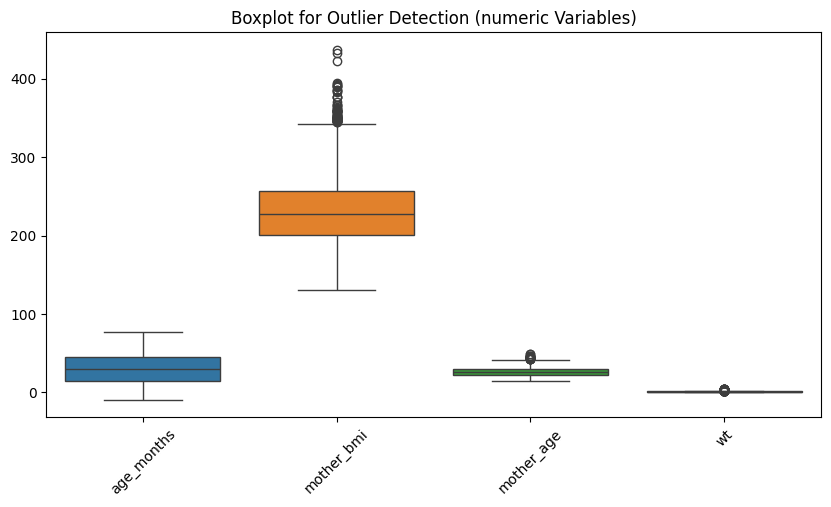

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[columns_to_check])
plt.xticks(rotation=45)
plt.title("Boxplot for Outlier Detection (numeric Variables)")
plt.show()



## wisker use to handle outlier

In [ ]:
import pandas as pd
import numpy as np

# 1. Define a helper to calculate bounds (Q1 - 1.5*IQR, Q3 + 1.5*IQR)
def get_winsorize_bounds(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return lower, upper

cols = ['age_months','mother_bmi','mother_age','wt']

for col in cols:
    # Calculate bounds
    lw, uw = get_winsorize_bounds(df[col])

    # Clip values between lw and uw
    df[col] = df[col].clip(lower=lw, upper=uw)

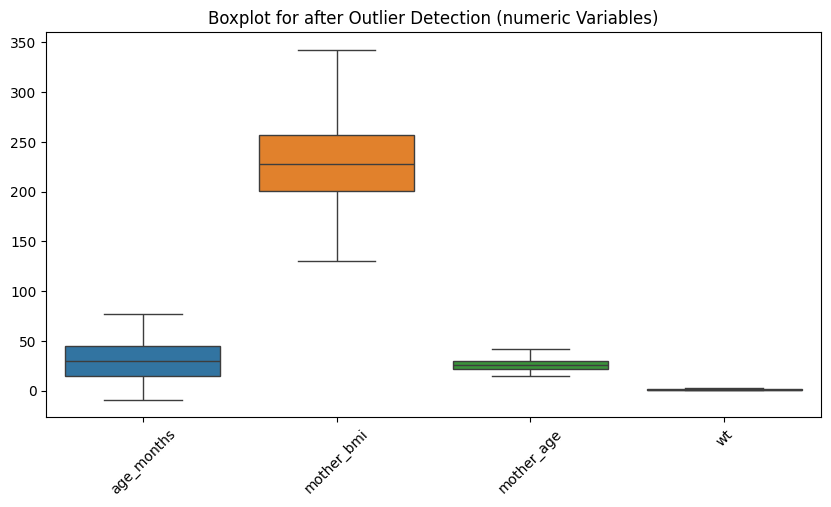

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[columns_to_check])
plt.xticks(rotation=45)
plt.title("Boxplot for after Outlier Detection (numeric Variables)")
plt.show()

### Scaling numerical variables

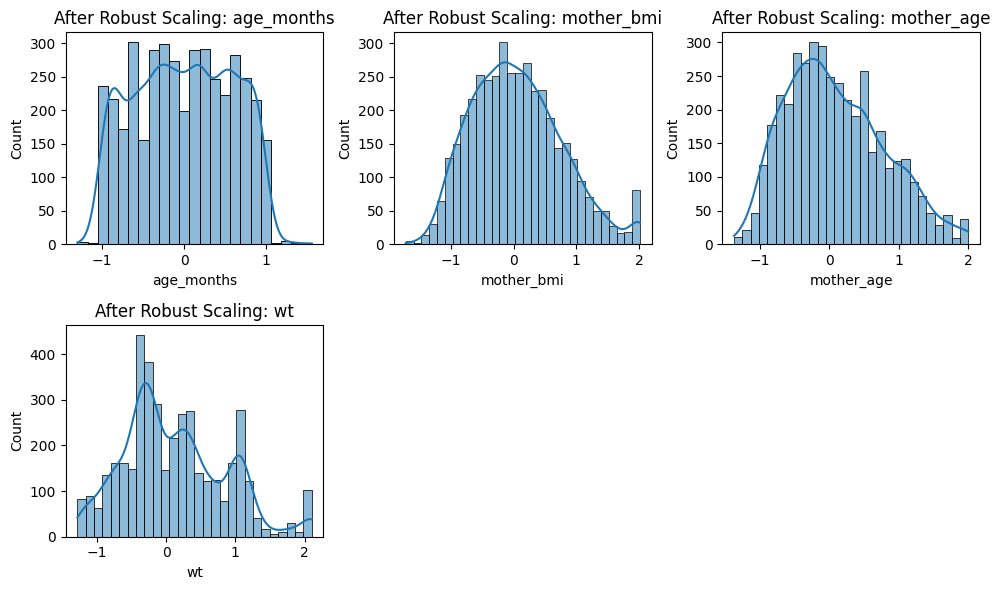

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
import pandas as pd

# Columns to scale
cols_to_scale = [
    'age_months',
    'mother_bmi',

    'mother_age',

    'wt'
]

# Apply Robust Scaling
scaler = RobustScaler()
scaled_values = scaler.fit_transform(df[cols_to_scale])

scaled_df = pd.DataFrame(
    scaled_values,
    columns=cols_to_scale,
    index=df.index
)

# Plot distributions after scaling
plt.figure(figsize=(10, 6))
for i, col in enumerate(cols_to_scale):
    plt.subplot(2, 3, i + 1)
    sns.histplot(scaled_df[col], kde=True)
    plt.title(f"After Robust Scaling: {col}")

plt.tight_layout()
plt.show()


# class imbalance checking

In [ ]:
# Class counts
stunted_counts = df['stunted'].value_counts()

# Class percentages
stunted_percent = df['stunted'].value_counts(normalize=True) * 100

print("Class Counts:")
print(stunted_counts)

print("\nClass Percentages (%):")
print(stunted_percent.round(2))


Class Counts:
stunted
0    3139
1     966
Name: count, dtype: int64

Class Percentages (%):
stunted
0    76.47
1    23.53
Name: proportion, dtype: float64


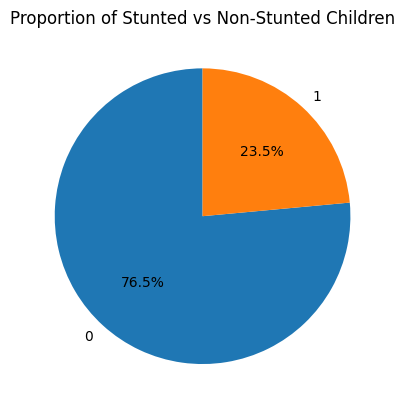

In [ ]:
df['stunted'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)
plt.ylabel('')
plt.title('Proportion of Stunted vs Non-Stunted Children')
plt.show()


 SMOTE (Synthetic Minority Oversampling Technique)


# Train Test Split (80% train, 20% test)

In [ ]:
from sklearn.model_selection import train_test_split

# Features and target
X = df.drop(['stunted','haz'], axis=1) # Features
y = df['stunted']  # Target

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y  # important for class imbalance
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("Training target distribution:")
print(y_train.value_counts(normalize=True))


Training set shape: (3284, 20)
Test set shape: (821, 20)
Training target distribution:
stunted
0    0.764616
1    0.235384
Name: proportion, dtype: float64


 SMOTE (Synthetic Minority Oversampling Technique)

In [ ]:
# Ordinal encoding for wealth_3cat
wealth_map = {'poor': 0, 'middle': 1, 'rich': 2}
df['wealth_3cat'] = df['wealth_3cat'].map(wealth_map)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(class_weight='balanced')

Before SMOTE:
stunted
0    3964
1    1036
Name: count, dtype: int64

Percentage before SMOTE:
stunted
0    79.28
1    20.72
Name: proportion, dtype: float64

After SMOTE:
stunted
0    3964
1    3964
Name: count, dtype: int64

Percentage:
stunted
0    50.0
1    50.0
Name: proportion, dtype: float64


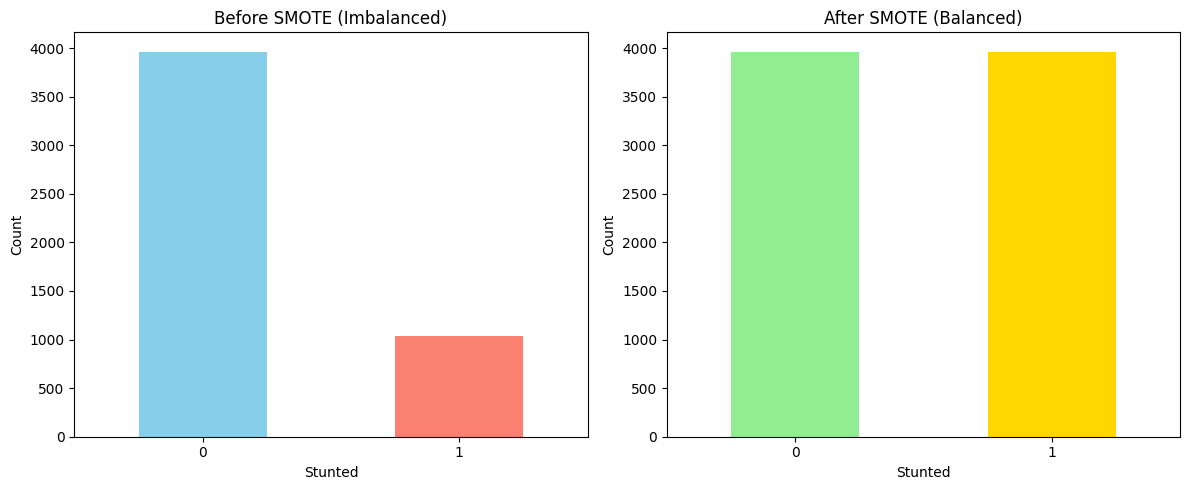

In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# Sample data (replace with your actual dataset)
np.random.seed(42)
n_samples = 5000
data = pd.DataFrame({
    'feature1': np.random.randn(n_samples),
    'feature2': np.random.randn(n_samples),
    'feature3': np.random.randn(n_samples),
    'stunted': np.random.choice([0, 1], size=n_samples, p=[0.8, 0.2])  # Imbalanced
})

print("Before SMOTE:")
print(data['stunted'].value_counts())
print("\nPercentage before SMOTE:")
print(data['stunted'].value_counts(normalize=True) * 100)

# Prepare features and target
X = data.drop('stunted', axis=1)
y = data['stunted']

X_train = np.nan_to_num(X_train)  # Done!
X_test = np.nan_to_num(X_test)
# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Create resampled dataframe
data_resampled = pd.DataFrame(X_resampled, columns=X.columns)
data_resampled['stunted'] = y_resampled

print("\n" + "="*50)
print("After SMOTE:")
print(data_resampled['stunted'].value_counts())
print("\nPercentage:")
print(data_resampled['stunted'].value_counts(normalize=True) * 100)

# Visualization
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
data['stunted'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Before SMOTE (Imbalanced)')
plt.xlabel('Stunted')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
data_resampled['stunted'].value_counts().plot(kind='bar', color=['lightgreen', 'gold'])
plt.title('After SMOTE (Balanced)')
plt.xlabel('Stunted')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

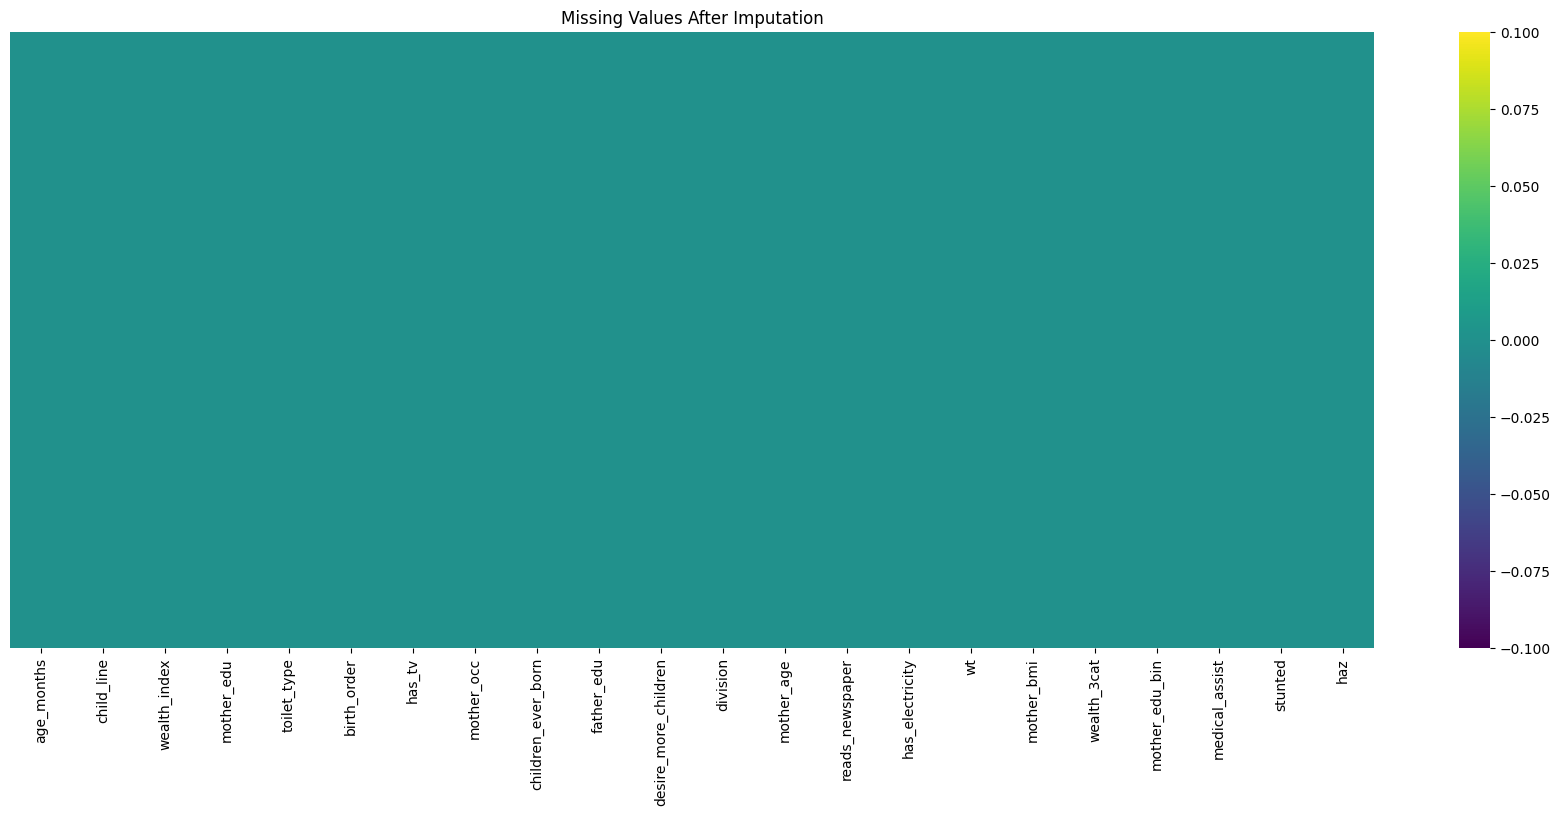

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(22,8))  # make it wide enough for all columns
sns.heatmap(df.isnull(),
            yticklabels=False,
            cbar=True,
            cmap='viridis')

plt.title("Missing Values After Imputation")
plt.show()

In [ ]:
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Variable': missing_percent.index,
    'Missing_Percent': missing_percent.values
}).sort_values(by='Missing_Percent', ascending=False)

print(missing_df)

                Variable  Missing_Percent
0             age_months              0.0
1             child_line              0.0
2           wealth_index              0.0
3             mother_edu              0.0
4            toilet_type              0.0
5            birth_order              0.0
6                 has_tv              0.0
7             mother_occ              0.0
8     children_ever_born              0.0
9             father_edu              0.0
10  desire_more_children              0.0
11              division              0.0
12            mother_age              0.0
13       reads_newspaper              0.0
14       has_electricity              0.0
15                    wt              0.0
16            mother_bmi              0.0
17           wealth_3cat              0.0
18        mother_edu_bin              0.0
19        medical_assist              0.0
20               stunted              0.0
21                   haz              0.0


# feature  engineering

In [ ]:

for i, feat in enumerate(df, start=1):
    print(f"{i}. {feat}")


1. age_months
2. child_line
3. wealth_index
4. mother_edu
5. toilet_type
6. birth_order
7. has_tv
8. mother_occ
9. children_ever_born
10. father_edu
11. desire_more_children
12. division
13. mother_age
14. reads_newspaper
15. has_electricity
16. wt
17. mother_bmi
18. wealth_3cat
19. mother_edu_bin
20. medical_assist
21. stunted
22. haz


# 1. Filter Method: SelectKBest with Mutual Information

This selects top features based on mutual information (measures dependency between features and target).
It's fast and doesn't overfit, but ignores feature interactions.

In [ ]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.model_selection import train_test_split
import pandas as pd

# Assuming df is your DataFrame
X = df.drop(['stunted','haz'], axis=1) # Features
y = df['stunted']  # Target

# Split data (optional, but recommended for evaluation)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

X_train = np.nan_to_num(X_train)  # Done!
X_test = np.nan_to_num(X_test)
# Initialize filter selector (select top 10 features; adjust k as needed)
selector = SelectKBest(score_func=mutual_info_classif, k=15)

# Fit and transform
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)



# Feature names from ORIGINAL X DataFrame
selected_features = X.columns[selector.get_support()]
print("Selected features:")
for i, feat in enumerate(selected_features, 1):
    print(f"{i}. {feat}")
# Now use X_train_selected and X_test_selected for modeling

Selected features:
1. age_months
2. wealth_index
3. mother_edu
4. toilet_type
5. birth_order
6. has_tv
7. children_ever_born
8. father_edu
9. mother_age
10. reads_newspaper
11. wt
12. mother_bmi
13. wealth_3cat
14. mother_edu_bin
15. medical_assist


# 2. Wrapper Method: Recursive Feature Elimination (RFE) with LogisticRegression
This recursively removes least important features using a model (here, LogisticRegression for multiclass). More accurate but slower.

In [ ]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import pandas as pd

# Assuming df is your DataFrame
X = df.drop(['stunted','haz'], axis=1)
y = df['stunted']  # Target

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Initialize wrapper selector (select top 10 features; adjust n_features_to_select)
estimator = LogisticRegression(random_state=42, max_iter=1000)  # Or use CatBoostClassifier for better performance
selector = RFE(estimator, n_features_to_select=15)

X_train = np.nan_to_num(X_train)  # Done!
X_test = np.nan_to_num(X_test)
# Fit and transform
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

# Get selected feature names
selected_features = X.columns[selector.get_support()]
print("Selected features:")
for i, feat in enumerate(selected_features, 1):
    print(f"{i}. {feat}")
# Now use X_train_selected
# Now use X_train_selected and X_test_selected for modeling

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Selected features:
1. child_line
2. wealth_index
3. mother_edu
4. birth_order
5. has_tv
6. children_ever_born
7. father_edu
8. desire_more_children
9. division
10. reads_newspaper
11. has_electricity
12. wt
13. wealth_3cat
14. mother_edu_bin
15. medical_assist


# 3.Stepwise Backward Feature Selection Code

In [ ]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import pandas as pd

# Assuming df is your DataFrame, and categoricals are encoded (from previous code)
X = df.drop(['stunted','haz'], axis=1)
y = df['stunted']  # Target

# Split data (stratified for imbalance)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Initialize backward selector (RFE with LogisticRegression; select top 10 features)
estimator = LogisticRegression(random_state=42, max_iter=1000)  # Or CatBoostClassifier
selector = RFE(estimator, n_features_to_select=15, step=1)  # step=1 removes 1 feature per iteration


X_train = np.nan_to_num(X_train)  # Done!
X_test = np.nan_to_num(X_test)
# Fit on training data
selector.fit(X_train, y_train)

# Get selected features
selected_features = X.columns[selector.get_support()]
print("Selected features:")
for i, feat in enumerate(selected_features, 1):
    print(f"{i}. {feat}")

# Transform data to selected features
X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test)

# Now use X_train_selected and X_test_selected for modeling (e.g., train CatBoost)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Selected features:
1. child_line
2. wealth_index
3. mother_edu
4. birth_order
5. has_tv
6. children_ever_born
7. father_edu
8. desire_more_children
9. division
10. reads_newspaper
11. has_electricity
12. wt
13. wealth_3cat
14. mother_edu_bin
15. medical_assist


# 4.Boruta Algorithm

In [ ]:
!pip install boruta


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 2.1 MB/s eta 0:00:00


In [ ]:
from boruta import BorutaPy


In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from boruta import BorutaPy
import pandas as pd
import numpy as np

# Fix your Boruta prep
X_train_boruta = pd.DataFrame(X_train, columns=X.columns).drop(columns=['haz'], errors='ignore')
X_test_boruta  = pd.DataFrame(X_test, columns=X.columns).drop(columns=['haz'], errors='ignore')

# Boruta needs NumPy arrays
X_train_np = X_train_boruta.values
X_test_np = X_test_boruta.values
y_train_np = y_train.values if hasattr(y_train, 'values') else y_train

print(f"✅ Boruta ready - Train shape: {X_train_np.shape}")


✅ Boruta ready - Train shape: (3284, 20)


In [ ]:
rf = RandomForestClassifier(
    n_estimators=500,
    random_state=45,
    n_jobs=-1,
    class_weight='balanced'
)


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from boruta import BorutaPy

# Assuming df is your preprocessed DataFrame (no strings, no NaNs)
# If not, add preprocessing here:
# from sklearn.preprocessing import LabelEncoder
# categorical_cols = ['wealth_index']  # Replace with your categorical columns
# for col in categorical_cols:
#     le = LabelEncoder()
#     df[col] = le.fit_transform(df[col])
# from sklearn.impute import IterativeImputer
# imputer = IterativeImputer(random_state=42)
# df[df.columns] = imputer.fit_transform(df)

X = df.drop(['stunted','haz'], axis=1)
y = df['stunted']

X_train = np.nan_to_num(X_train)  # Done!
X_test = np.nan_to_num(X_test)

# Check df for issues before splitting
print("Data types in df:")
print(df.dtypes)
print("Any NaNs in df?", df.isnull().sum().sum() > 0)
print("Any non-numerical in X?", X.select_dtypes(include=[object]).shape[1] > 0)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Convert to numpy (with checks)
try:
    X_train_np = np.array(X_train.values if hasattr(X_train, 'values') else X_train)
    y_train_np = np.array(y_train.values if hasattr(y_train, 'values') else y_train)
except Exception as e:
    print(f"Conversion error: {e}")
    raise


# Validate shapes and types
print("X_train_np shape:", X_train_np.shape, "Type:", type(X_train_np))
print("y_train_np shape:", y_train_np.shape, "Type:", type(y_train_np))
if X_train_np.ndim != 2:
    raise ValueError("X_train_np must be 2D. Reshape if needed.")
if y_train_np.ndim != 1:
    raise ValueError("y_train_np must be 1D.")

# Initialize RF
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Boruta
boruta = BorutaPy(estimator=rf, n_estimators='auto', verbose=2, random_state=45)



# Fit with try-except
try:
    boruta.fit(X_train_np, y_train_np)
    selected_features = X.columns[boruta.support_].tolist()
    print("Selected features:", selected_features)
except ValueError as e:
    print(f"Boruta fit error: {e}")
    print("Likely cause: Check data preprocessing or shapes above.")

Data types in df:
age_months               float64
child_line                 int64
wealth_index            category
mother_edu              category
toilet_type             category
birth_order             category
has_tv                  category
mother_occ              category
children_ever_born       float64
father_edu              category
desire_more_children    category
division                category
mother_age               float64
reads_newspaper         category
has_electricity         category
wt                       float64
mother_bmi               float64
wealth_3cat             category
mother_edu_bin          category
medical_assist          category
stunted                 category
haz                      float64
dtype: object
Any NaNs in df? False
Any non-numerical in X? False
X_train_np shape: (3284, 20) Type: <class 'numpy.ndarray'>
y_train_np shape: (3284,) Type: <class 'numpy.ndarray'>
Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	20
Rejected: 	0
Iteration: 	2

# 5.Grey Wolf Optimizer (GWO)  Feature Selection

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.8 MB/s eta 0:00:00


In [ ]:
import numpy as np
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from catboost import CatBoostClassifier

# Assuming df is your DataFrame (categoricals encoded, NaNs imputed)
X = df.drop(['stunted','haz'], axis=1)
y = df['stunted'].values
n_features = X.shape[1]

# Split for fitness evaluation (to avoid overfitting)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# GWO Parameters (reduced for testing)
n_wolves = 10  # Smaller population
max_iter = 20  # Fewer iterations
a_max = 2
a_min = 0

# Fitness function: Accuracy on test set (faster than CV)
def fitness_function(subset, X_train, X_test, y_train, y_test):
    if np.sum(subset) == 0:  # Avoid empty subsets
        return 0
    try:
        selected_train = X_train[:, subset == 1]
        selected_test = X_test[:, subset == 1]
        model = CatBoostClassifier(iterations=50, verbose=0, random_state=42)
        model.fit(selected_train, y_train)
        y_pred = model.predict(selected_test)
        return accuracy_score(y_test, y_pred)
    except Exception as e:
        print(f"Fitness error: {e}")
        return 0

# Initialize population
population = np.random.randint(0, 2, (n_wolves, n_features))

# Initialize best wolves
alpha_pos = np.copy(population[0])
beta_pos = np.copy(population[1])
delta_pos = np.copy(population[2])
alpha_score = 0
beta_score = 0
delta_score = 0

# GWO Loop
for iter in range(max_iter):
    a = a_max - (a_max - a_min) * (iter / max_iter)

    for i in range(n_wolves):
        fitness = fitness_function(population[i], X_train, X_test, y_train, y_test)

        if fitness > alpha_score:
            alpha_score = fitness
            alpha_pos = np.copy(population[i])
        elif fitness > beta_score:
            beta_score = fitness
            beta_pos = np.copy(population[i])
        elif fitness > delta_score:
            delta_score = fitness
            delta_pos = np.copy(population[i])

    # Update positions with sigmoid for binary
    for i in range(n_wolves):
        for j in range(n_features):
            r1, r2 = np.random.rand(), np.random.rand()
            A1 = 2 * a * r1 - a
            C1 = 2 * r2
            D_alpha = abs(C1 * alpha_pos[j] - population[i][j])
            X1 = alpha_pos[j] - A1 * D_alpha

            r1, r2 = np.random.rand(), np.random.rand()
            A2 = 2 * a * r1 - a
            C2 = 2 * r2
            D_beta = abs(C2 * beta_pos[j] - population[i][j])
            X2 = beta_pos[j] - A2 * D_beta

            r1, r2 = np.random.rand(), np.random.rand()
            A3 = 2 * a * r1 - a
            C3 = 2 * r2
            D_delta = abs(C3 * delta_pos[j] - population[i][j])
            X3 = delta_pos[j] - A3 * D_delta

            new_pos = (X1 + X2 + X3) / 3
            population[i][j] = 1 if 1 / (1 + np.exp(-10 * (new_pos - 0.5))) > 0.5 else 0  # Sharper sigmoid

    print(f"Iter {iter+1}: Best Score = {alpha_score:.4f}")

# Results
selected_indices = np.where(alpha_pos == 1)[0]
selected_features = df.drop('stunted', axis=1).columns[selected_indices].tolist()
print("Selected features:", selected_features)
print("Best accuracy:", alpha_score)

Fitness error: (slice(None, None, None), array([False,  True, False,  True, False, False,  True, False, False,
        True,  True,  True,  True, False, False, False,  True,  True,
       False,  True]))
Fitness error: (slice(None, None, None), array([False, False, False, False, False,  True,  True,  True, False,
       False,  True,  True,  True, False,  True, False,  True,  True,
        True,  True]))
Fitness error: (slice(None, None, None), array([False, False,  True,  True,  True,  True, False,  True,  True,
       False,  True, False, False,  True, False, False,  True, False,
        True,  True]))
Fitness error: (slice(None, None, None), array([ True, False,  True,  True, False, False, False,  True,  True,
        True,  True, False, False,  True, False, False,  True,  True,
       False,  True]))
Fitness error: (slice(None, None, None), array([False, False,  True, False,  True, False, False, False, False,
        True, False,  True, False,  True, False,  True,  True, False,
   

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression  # Or CatBoostClassifier if installed

# Assuming df is your preprocessed DataFrame (categoricals encoded, NaNs imputed)
X = df.drop(['stunted','haz'], axis=1)
y = df['stunted'].values
n_features = X.shape[1]

# Split for fitness
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# SO Parameters
n_snakes = 20  # Population size
max_iter = 50  # Iterations
c1 = 1  # Control parameter
c2 = 0.5  # Another parameter

# Fitness function
def fitness_function(subset, X_train, X_test, y_train, y_test):
    if np.sum(subset) == 0:
        return 0
    try:
        selected_train = X_train[:, subset == 1]
        selected_test = X_test[:, subset == 1]
        model = LogisticRegression(random_state=42, max_iter=1000)
        model.fit(selected_train, y_train)
        y_pred = model.predict(selected_test)
        return accuracy_score(y_test, y_pred)
    except Exception as e:
        print(f"Fitness error: {e}")
        return 0

# Initialize population (binary)
population = np.random.randint(0, 2, (n_snakes, n_features))

# Initialize best snake
best_snake = np.copy(population[0])
best_fitness = 0

# SO Main Loop
for iter in range(max_iter):
    fitness_values = np.array([fitness_function(population[i], X_train, X_test, y_train, y_test) for i in range(n_snakes)])

    # Update best
    max_idx = np.argmax(fitness_values)
    if fitness_values[max_idx] > best_fitness:
        best_fitness = fitness_values[max_idx]
        best_snake = np.copy(population[max_idx])

    # Update population
    for i in range(n_snakes):
        for j in range(n_features):
            r1 = np.random.rand()
            r2 = np.random.rand()
            if r1 < c1:
                # Follow best snake
                population[i][j] = best_snake[j]
            elif r2 < c2:
                # Random walk
                population[i][j] = np.random.randint(0, 2)
            # Else, stay the same

    print(f"Iter {iter+1}: Best Fitness = {best_fitness:.4f}")

# Results
selected_indices = np.where(best_snake == 1)[0]
selected_features = df.drop('stunted', axis=1).columns[selected_indices].tolist()
print("Selected features:", selected_features)
print("Best accuracy:", best_fitness)

Fitness error: (slice(None, None, None), array([False, False, False,  True,  True, False, False, False,  True,
       False,  True,  True,  True,  True, False, False, False,  True,
        True, False]))
Fitness error: (slice(None, None, None), array([ True,  True, False, False, False,  True, False,  True,  True,
        True,  True, False,  True, False, False,  True,  True, False,
        True,  True]))
Fitness error: (slice(None, None, None), array([ True, False, False, False, False, False,  True, False, False,
       False,  True, False, False,  True, False, False, False,  True,
       False,  True]))
Fitness error: (slice(None, None, None), array([ True, False,  True, False,  True,  True,  True,  True, False,
        True,  True,  True, False, False,  True, False, False, False,
        True, False]))
Fitness error: (slice(None, None, None), array([False, False, False, False, False,  True,  True,  True, False,
       False, False,  True, False, False, False, False,  True,  True,
   

In [ ]:
print(X_train.dtypes)
print("Missing values:", X_train.isnull().sum().sum())

age_months               float64
child_line                 int64
wealth_index            category
mother_edu              category
toilet_type             category
birth_order             category
has_tv                  category
mother_occ              category
children_ever_born       float64
father_edu              category
desire_more_children    category
division                category
mother_age               float64
reads_newspaper         category
has_electricity         category
wt                       float64
mother_bmi               float64
wealth_3cat             category
mother_edu_bin          category
medical_assist          category
dtype: object
Missing values: 0


In [ ]:
X = df.drop(['stunted','haz'], axis=1)
y = df['stunted']

# convert all columns to numeric
X = X.apply(pd.to_numeric, errors='coerce')

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [ ]:
pip install xgboost lightgbm

In [ ]:
# 1️⃣ Import libraries
import numpy as np
import pandas as pd
import random
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectKBest, mutual_info_classif, RFE
from sklearn.linear_model import LogisticRegression, Lasso
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Fix seeds for reproducibility
np.random.seed(42)
random.seed(42)

# 2️⃣ Prepare data
X = df.drop(['stunted','haz'], axis=1)
y = df['stunted']

# Encode categorical columns
from sklearn.preprocessing import LabelEncoder

for col in X.select_dtypes(include=['object', 'category']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# 3️⃣ Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)


# 4️⃣ Feature Selection Methods

# MI
mi_selector = SelectKBest(score_func=mutual_info_classif, k='all')
mi_selector.fit(X_train, y_train)
mi_rank = pd.Series(mi_selector.scores_, index=X_train.columns).rank(ascending=False)

# RFE
rfe_model = LogisticRegression(max_iter=1000, random_state=42)
rfe_selector = RFE(rfe_model, n_features_to_select=10)
rfe_selector.fit(X_train, y_train)
rfe_rank = pd.Series(rfe_selector.ranking_, index=X_train.columns)

# RF Feature Importance
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_rank = pd.Series(rf_model.feature_importances_, index=X_train.columns).rank(ascending=False)

# LASSO Rank
lasso_model = Lasso(alpha=0.01, random_state=42)
lasso_model.fit(X_train, y_train)
lasso_rank = pd.Series(np.abs(lasso_model.coef_), index=X_train.columns).rank(ascending=False)

# Snake Rank (placeholder: using RF importance again)
snake_rank = pd.Series(rf_model.feature_importances_, index=X_train.columns).rank(ascending=False)
# Convert to NumPy (required for GWO)
X_train_np = X_train.values
X_test_np = X_test.values
n_features = X_train_np.shape[1]

#GWO Fitness Function
def fitness_function(subset):
    if np.sum(subset) == 0:
        return 0
    try:
        selected_train = X_train_np[:, subset == 1]
        selected_test = X_test_np[:, subset == 1]

        model = CatBoostClassifier(iterations=50, verbose=0, random_state=42)
        model.fit(selected_train, y_train)

        y_pred = model.predict(selected_test)
        return accuracy_score(y_test, y_pred)
    except:
        return 0
#Run GWO
n_wolves = 10
max_iter = 20

population = np.random.randint(0, 2, (n_wolves, n_features))

alpha_pos = population[0].copy()
alpha_score = 0

for iter in range(max_iter):
    for i in range(n_wolves):
        fitness = fitness_function(population[i])

        if fitness > alpha_score:
            alpha_score = fitness
            alpha_pos = population[i].copy()

    # Update (simplified for speed)
    for i in range(n_wolves):
        for j in range(n_features):
            prob = 1 / (1 + np.exp(-population[i][j]))
            population[i][j] = 1 if prob > 0.5 else 0
#GWO → Rank
gwo_rank = pd.Series(
    [1 if val == 1 else 5 for val in alpha_pos],  # selected=1, not selected=5
    index=X_train.columns
)
#
# Aggregate ranks
feature_rank_df = pd.DataFrame({
    'MI_Rank': mi_rank,
    'RFE_Rank': rfe_rank,
    'RF_Rank': rf_rank,
    'LASSO_Rank': lasso_rank,
    'Snake_Rank': snake_rank,
     'GWO_Rank': gwo_rank
})
feature_rank_df['Average_Rank'] = feature_rank_df.mean(axis=1)
feature_rank_df = feature_rank_df.sort_values('Average_Rank')

# Top features
top_features = feature_rank_df.index[:10]
X_train_selected = X_train[top_features]
X_test_selected = X_test[top_features]
print("Top features selected:", list(top_features))

# 5️⃣ Define ensemble of models
models = [
    ('LogReg', LogisticRegression(max_iter=1000, random_state=42)),
    ('SVM', SVC(probability=True, random_state=42)),
    ('AdaBoost', AdaBoostClassifier(n_estimators=100, random_state=42)),
    ('RandomForest', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('GradientBoost', GradientBoostingClassifier(n_estimators=100, random_state=42)),
    ('DecisionTree', DecisionTreeClassifier(random_state=42)),
    ('KNN', KNeighborsClassifier(n_neighbors=5)),
    ('NaiveBayes', GaussianNB()),

    ('XGBoost', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)),
    ('LightGBM', LGBMClassifier(random_state=42))
]

ensemble_model = VotingClassifier(estimators=models, voting='soft')

# 6️⃣ Stratified K-Fold Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(ensemble_model, X_train_selected, y_train, cv=cv, scoring='accuracy')
print("Cross-validation scores:", cv_scores)
print("Average CV Accuracy:", cv_scores.mean())

# 7️⃣ Train ensemble on full training set
ensemble_model.fit(X_train_selected, y_train)

# 8️⃣ Predict on test set
y_pred = ensemble_model.predict(X_test_selected)

# 9️⃣ Evaluate
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Top features selected: ['wealth_index', 'mother_bmi', 'father_edu', 'toilet_type', 'age_months', 'children_ever_born', 'mother_edu', 'wt', 'mother_age', 'division']


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:00:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 624, number of negative: 2003
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002804 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 655
[LightGBM] [Info] Number of data points in the train set: 2627, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.237533 -> initscore=-1.166251
[LightGBM] [Info] Start training from score -1.166251


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:00:33] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


...

[LightGBM] [Info] Number of positive: 625, number of negative: 2002
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000140 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 656
[LightGBM] [Info] Number of data points in the train set: 2627, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.237914 -> initscore=-1.164150
[LightGBM] [Info] Start training from score -1.164150


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:00:43] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 625, number of negative: 2003
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000139 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 652
[LightGBM] [Info] Number of data points in the train set: 2628, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.237823 -> initscore=-1.164650
[LightGBM] [Info] Start training from score -1.164650
Cross-validation scores: [0.7564688  0.75038052 0.75342466 0.74581431 0.75457317]
Average CV Accuracy: 0.752132290158518


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:00:47] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 781, number of negative: 2503
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000170 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 664
[LightGBM] [Info] Number of data points in the train set: 3284, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.237820 -> initscore=-1.164670
[LightGBM] [Info] Start training from score -1.164670
Test Accuracy: 0.7771010962241169

Confusion Matrix:
 [[618  18]
 [165  20]]

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.97      0.87       636
           1       0.53      0.11      0.18       185

    accuracy                           0.78       821
   macro avg       0.66      0.54      0.53       821
weighted avg       0.73      0.78      0.72       821



In [ ]:
rank_df = pd.DataFrame({
    'MI_Rank': mi_rank,
    'RFE_Rank': rfe_rank,
    'RF_Rank': rf_rank,

   'LASSO_Rank': lasso_rank,
     'Snake_Rank': snake_rank,
        'GWO_Rank': gwo_rank,
})

In [ ]:
top_features = rank_df.head(15)

print("\nTop Features After Aggregation:")
print(top_features)


Top Features After Aggregation:
                      MI_Rank  RFE_Rank  RF_Rank  LASSO_Rank  Snake_Rank  \
age_months                8.0         8      2.0         7.0         2.0   
child_line               17.0         7     17.0        15.5        17.0   
wealth_index              4.0         1      8.0         2.0         8.0   
mother_edu                2.0         1     12.0         1.0        12.0   
toilet_type               3.0         9      5.0         5.0         5.0   
birth_order              13.0        10     10.0         8.0        10.0   
has_tv                    6.0         4     13.0        15.5        13.0   
mother_occ               10.0         1     15.0        15.5        15.0   
children_ever_born        7.0         1      9.0         3.0         9.0   
father_edu                5.0         3      7.0         4.0         7.0   
desire_more_children     19.5         1     11.0        15.5        11.0   
division                 16.0         5      6.0       

In [ ]:
top_features = rank_df.head(15)

In [ ]:
selected_features = top_features.index

In [ ]:
# CREATE NEW DATASET WITH SELECTED FEATURES
X_selected = X[selected_features]
print(f"\n📈 Original features: {X.shape[1]} → Selected features: {X_selected.shape[1]}")
print(f"Feature reduction: {100*(1 - X_selected.shape[1]/X.shape[1]):.1f}%")


📈 Original features: 20 → Selected features: 15
Feature reduction: 25.0%


In [ ]:
# SAVE SELECTED FEATURES (Optional)
selected_features_df = pd.DataFrame({'selected_features': selected_features})
selected_features_df.to_csv('selected_features.csv', index=False)
print("\n💾 Selected features saved to 'selected_features.csv'")


💾 Selected features saved to 'selected_features.csv'


In [ ]:
# Now use X_selected and selected_features in your models!
print(f"\n🎯 Ready to use: X_selected and selected_features")
print("X_selected.shape =", X_selected.shape)


🎯 Ready to use: X_selected and selected_features
X_selected.shape = (4105, 15)


# 2. Logistic Regression

LOGISTIC REGRESSION RESULTS
F1-Score: 0.0498
ROC AUC: 0.6645
TN: 625, FP: 3, FN: 188, TP: 5

Classification Report:
              precision    recall  f1-score   support

           0       0.77      1.00      0.87       628
           1       0.62      0.03      0.05       193

    accuracy                           0.77       821
   macro avg       0.70      0.51      0.46       821
weighted avg       0.73      0.77      0.68       821



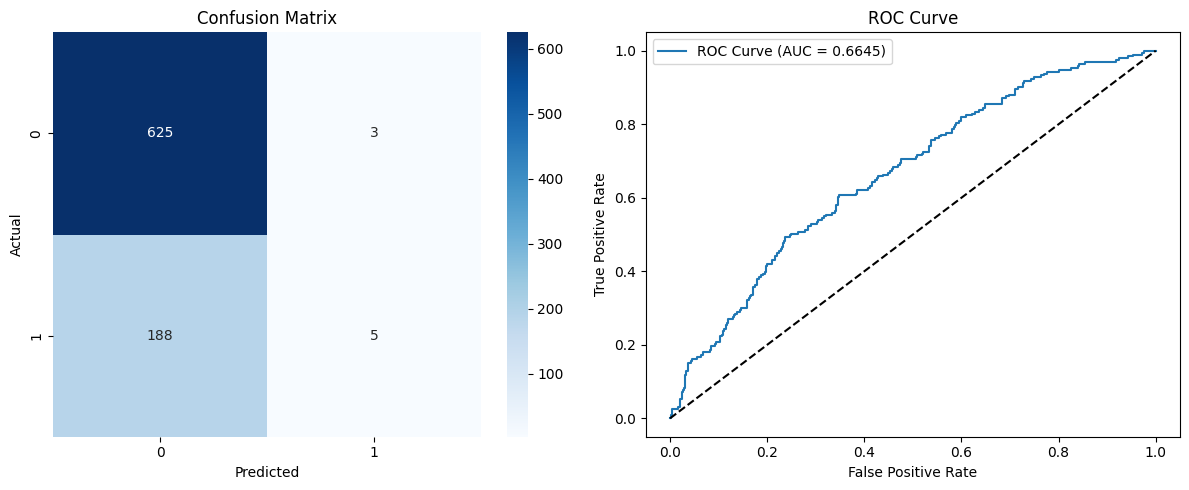

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Load your data (replace with your actual data)
# X = your_features
# y = your_target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

# Predictions
y_pred = lr.predict(X_test_scaled)
y_pred_proba = lr.predict_proba(X_test_scaled)[:, 1]

# Metrics
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("LOGISTIC REGRESSION RESULTS")
print(f"F1-Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Visualizations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1)
ax1.set_title('Confusion Matrix')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

# ROC Curve
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
ax2.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax2.plot([0,1], [0,1], 'k--')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve')
ax2.legend()

plt.tight_layout()
plt.show()

# 3. K-Nearest Neighbors

K-NEAREST NEIGHBORS RESULTS
F1-Score: 0.2035
ROC AUC: 0.5599
TN: 565, FP: 63, FN: 164, TP: 29

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.90      0.83       628
           1       0.32      0.15      0.20       193

    accuracy                           0.72       821
   macro avg       0.55      0.52      0.52       821
weighted avg       0.67      0.72      0.68       821



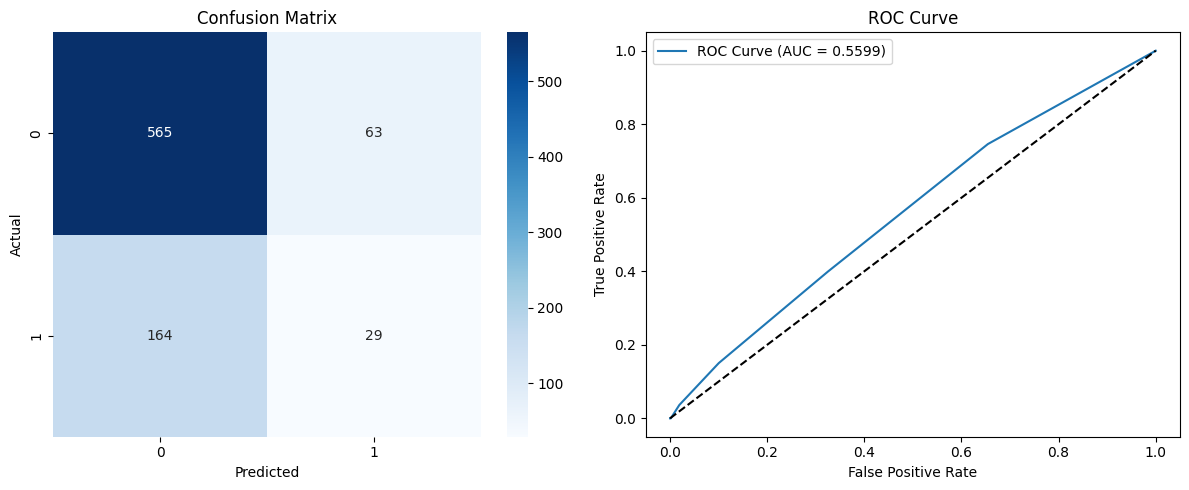

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Same data prep as above
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# Predictions
y_pred = knn.predict(X_test_scaled)
y_pred_proba = knn.predict_proba(X_test_scaled)[:, 1]

# Metrics
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("K-NEAREST NEIGHBORS RESULTS")
print(f"F1-Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Visualizations (same as above)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1)
ax1.set_title('Confusion Matrix')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
ax2.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax2.plot([0,1], [0,1], 'k--')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve')
ax2.legend()

plt.tight_layout()
plt.show()

## 4. Decision Tree

DECISION TREE RESULTS
F1-Score: 0.1101
ROC AUC: 0.6511
TN: 615, FP: 13, FN: 181, TP: 12

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.98      0.86       628
           1       0.48      0.06      0.11       193

    accuracy                           0.76       821
   macro avg       0.63      0.52      0.49       821
weighted avg       0.70      0.76      0.69       821



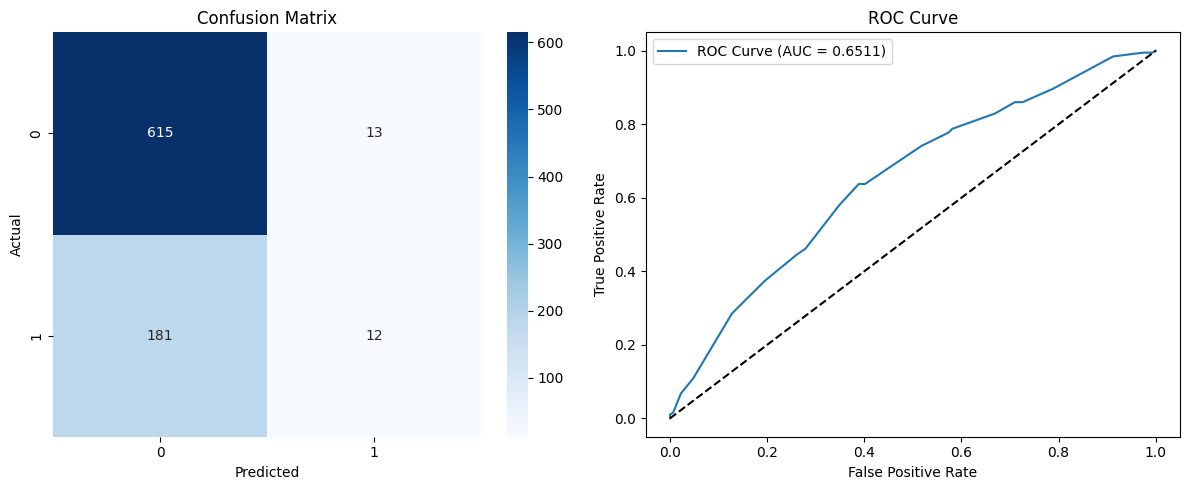

In [ ]:
from sklearn.tree import DecisionTreeClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train Decision Tree
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)
y_pred_proba = dt.predict_proba(X_test)[:, 1]

# Metrics
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("DECISION TREE RESULTS")
print(f"F1-Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Visualizations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1)
ax1.set_title('Confusion Matrix')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
ax2.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax2.plot([0,1], [0,1], 'k--')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve')
ax2.legend()

plt.tight_layout()
plt.show()

# 5. Random Forest

RANDOM FOREST RESULTS
F1-Score: 0.0577
ROC AUC: 0.6567
TN: 619, FP: 9, FN: 187, TP: 6

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.99      0.86       628
           1       0.40      0.03      0.06       193

    accuracy                           0.76       821
   macro avg       0.58      0.51      0.46       821
weighted avg       0.68      0.76      0.67       821



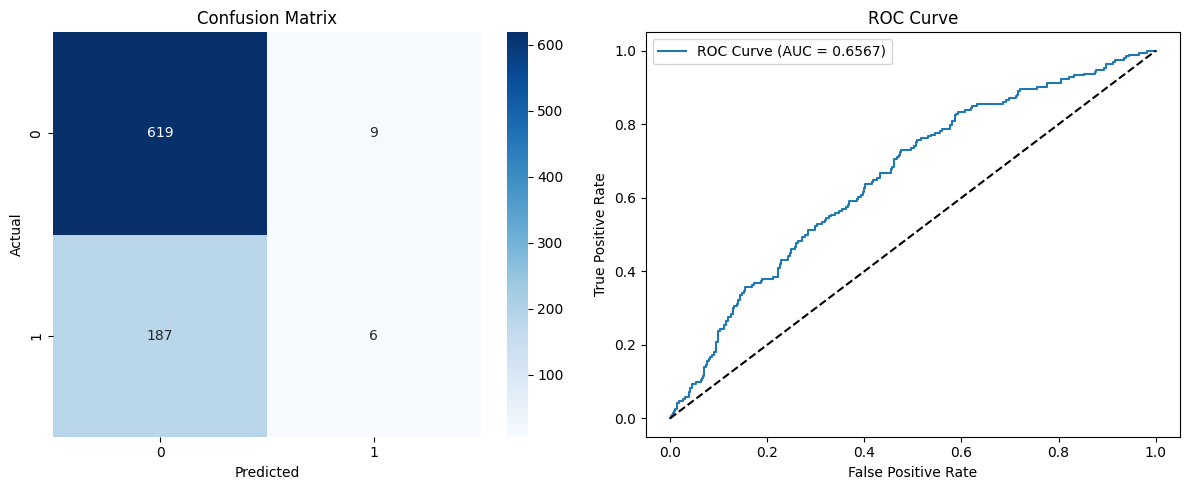

In [ ]:
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train Random Forest
rf = RandomForestClassifier(max_depth=10, n_estimators=200, n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_pred_proba = rf.predict_proba(X_test)[:, 1]

# Metrics
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("RANDOM FOREST RESULTS")
print(f"F1-Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Visualizations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1)
ax1.set_title('Confusion Matrix')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
ax2.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax2.plot([0,1], [0,1], 'k--')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve')
ax2.legend()

plt.tight_layout()
plt.show()

## 6. Gradient Boosting

GRADIENT BOOSTING RESULTS
F1-Score: 0.1256
ROC AUC: 0.6417
TN: 612, FP: 16, FN: 179, TP: 14

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.97      0.86       628
           1       0.47      0.07      0.13       193

    accuracy                           0.76       821
   macro avg       0.62      0.52      0.49       821
weighted avg       0.70      0.76      0.69       821



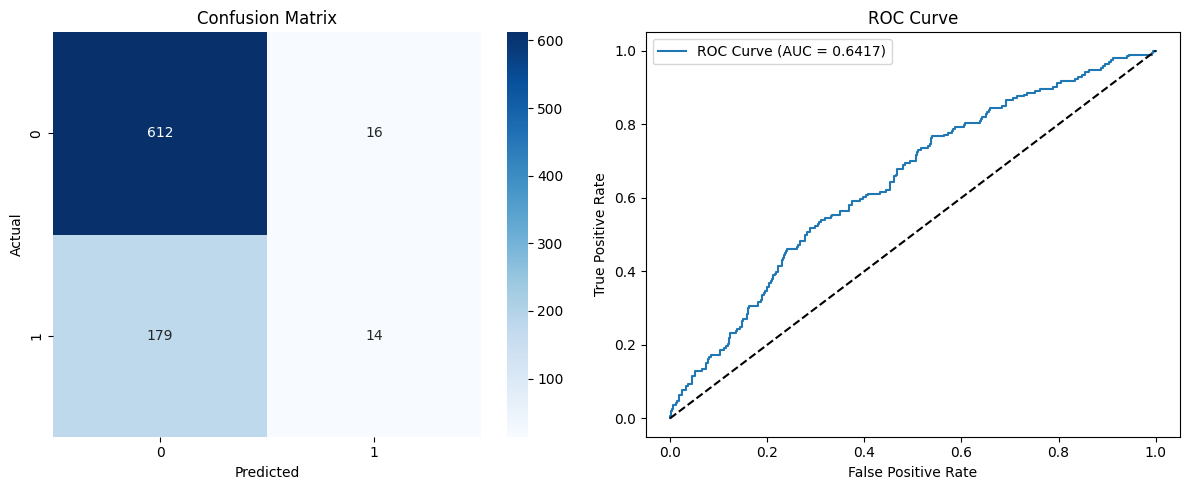

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)

y_pred = gb.predict(X_test)
y_pred_proba = gb.predict_proba(X_test)[:, 1]

# Metrics
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("GRADIENT BOOSTING RESULTS")
print(f"F1-Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Visualizations (same as above)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1)
ax1.set_title('Confusion Matrix')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
ax2.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax2.plot([0,1], [0,1], 'k--')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve')
ax2.legend()

plt.tight_layout()
plt.show()

## 7. AdaBoost

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


ADABOOST RESULTS
F1-Score: 0.0683
ROC AUC: 0.6541
TN: 623, FP: 5, FN: 186, TP: 7

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.99      0.87       628
           1       0.58      0.04      0.07       193

    accuracy                           0.77       821
   macro avg       0.68      0.51      0.47       821
weighted avg       0.73      0.77      0.68       821



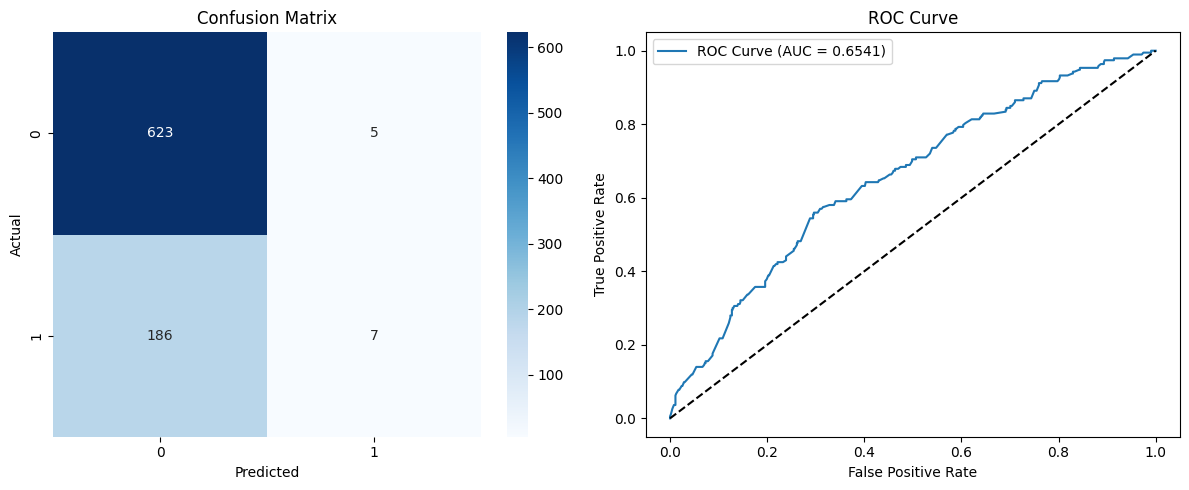

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train AdaBoost
ada = AdaBoostClassifier(n_estimators=100, random_state=42, algorithm='SAMME')
ada.fit(X_train, y_train)

y_pred = ada.predict(X_test)
y_pred_proba = ada.predict_proba(X_test)[:, 1]

# Metrics
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("ADABOOST RESULTS")
print(f"F1-Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Visualizations (same as above)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1)
ax1.set_title('Confusion Matrix')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
ax2.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax2.plot([0,1], [0,1], 'k--')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve')
ax2.legend()

plt.tight_layout()
plt.show()

# 8. SVM

SVM RESULTS
F1-Score: 0.0101
ROC AUC: 0.5828
TN: 624, FP: 4, FN: 192, TP: 1

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.99      0.86       628
           1       0.20      0.01      0.01       193

    accuracy                           0.76       821
   macro avg       0.48      0.50      0.44       821
weighted avg       0.63      0.76      0.66       821



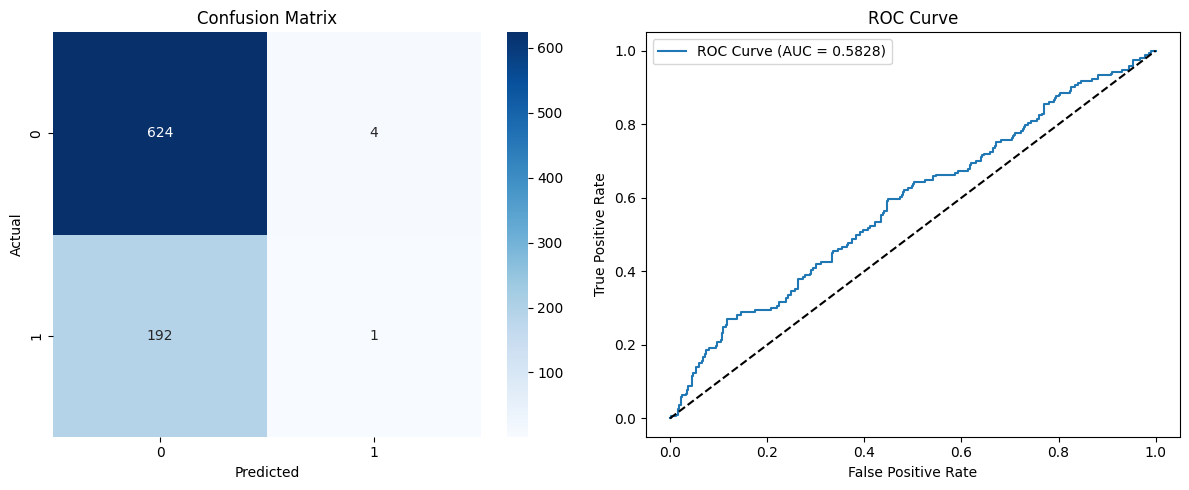

In [ ]:
from sklearn.svm import SVC

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train SVM
svm = SVC(kernel='rbf', probability=True, random_state=42)
svm.fit(X_train_scaled, y_train)

y_pred = svm.predict(X_test_scaled)
y_pred_proba = svm.predict_proba(X_test_scaled)[:, 1]

# Metrics
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("SVM RESULTS")
print(f"F1-Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Visualizations (same as above)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1)
ax1.set_title('Confusion Matrix')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
ax2.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax2.plot([0,1], [0,1], 'k--')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve')
ax2.legend()

plt.tight_layout()
plt.show()

# 9. Naive Bayes

NAIVE BAYES RESULTS
F1-Score: 0.4054
ROC AUC: 0.6391
TN: 467, FP: 161, FN: 103, TP: 90

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.74      0.78       628
           1       0.36      0.47      0.41       193

    accuracy                           0.68       821
   macro avg       0.59      0.60      0.59       821
weighted avg       0.71      0.68      0.69       821



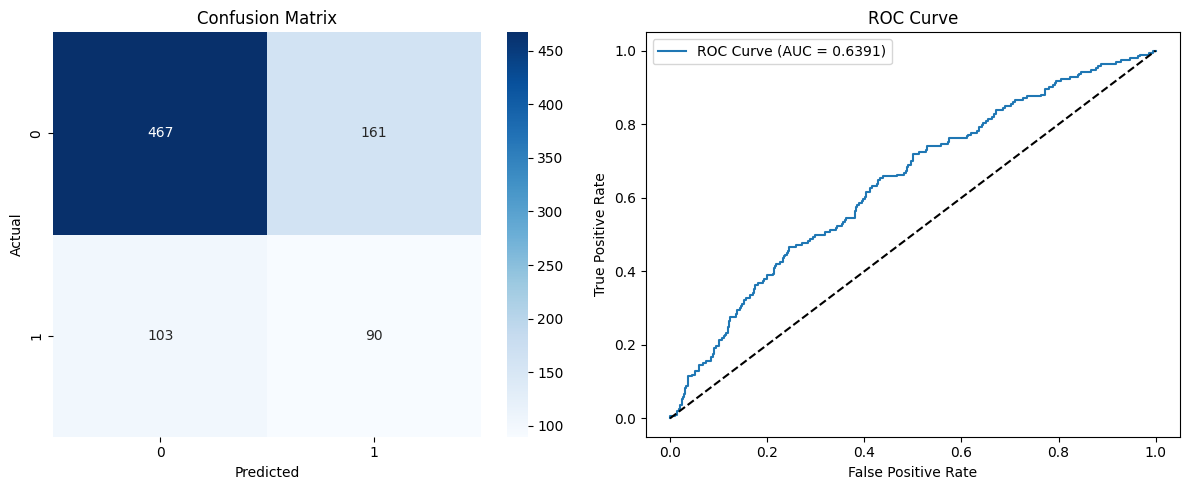

In [ ]:
from sklearn.naive_bayes import GaussianNB

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train Naive Bayes
nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred = nb.predict(X_test)
y_pred_proba = nb.predict_proba(X_test)[:, 1]

# Metrics
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("NAIVE BAYES RESULTS")
print(f"F1-Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Visualizations (same as above)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1)
ax1.set_title('Confusion Matrix')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
ax2.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax2.plot([0,1], [0,1], 'k--')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve')
ax2.legend()

plt.tight_layout()
plt.show()

# 2. LightGBM

In [ ]:
pip install lightgbm

LIGHTGBM RESULTS
F1-Score: 0.1957
ROC AUC: 0.6114
TN: 572, FP: 56, FN: 166, TP: 27

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.91      0.84       628
           1       0.33      0.14      0.20       193

    accuracy                           0.73       821
   macro avg       0.55      0.53      0.52       821
weighted avg       0.67      0.73      0.69       821



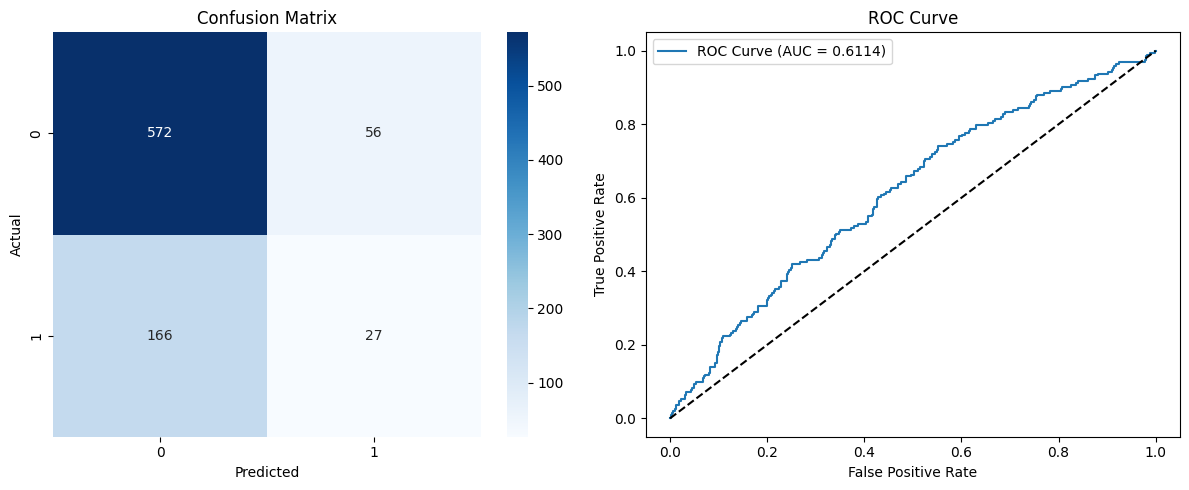

In [ ]:
import lightgbm as lgb
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train LightGBM
lgb_model = lgb.LGBMClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgb_model.fit(X_train, y_train)

y_pred = lgb_model.predict(X_test)
y_pred_proba = lgb_model.predict_proba(X_test)[:, 1]

# Metrics
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("LIGHTGBM RESULTS")
print(f"F1-Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Visualizations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1)
ax1.set_title('Confusion Matrix')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
ax2.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax2.plot([0,1], [0,1], 'k--')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve')
ax2.legend()

plt.tight_layout()
plt.show()

# 1. XGBoost

In [ ]:
pip install --upgrade xgboost

XGBoost RESULTS
F1-Score: 0.2097
ROC AUC: 0.6329
TN: 582, FP: 46, FN: 165, TP: 28

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.93      0.85       628
           1       0.38      0.15      0.21       193

    accuracy                           0.74       821
   macro avg       0.58      0.54      0.53       821
weighted avg       0.68      0.74      0.70       821



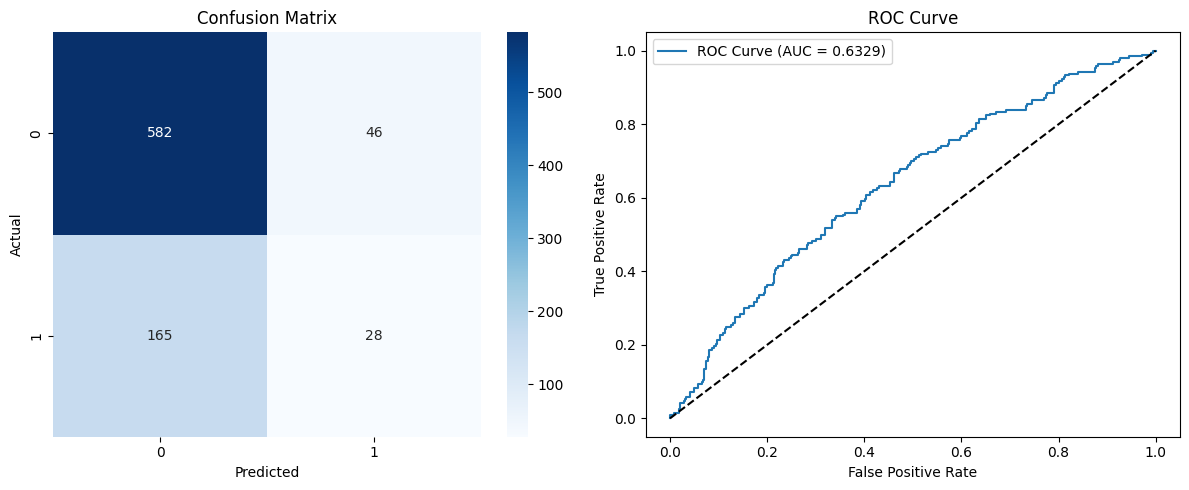

In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


# Train XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train_scaled, y_train)

y_pred = xgb_model.predict(X_test_scaled)
y_pred_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]

# Metrics
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("XGBoost RESULTS")
print(f"F1-Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Visualizations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1)
ax1.set_title('Confusion Matrix')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
ax2.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax2.plot([0,1], [0,1], 'k--')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve')
ax2.legend()

plt.tight_layout()
plt.show()

XGBoost RESULTS
F1-Score: 0.2097
ROC AUC: 0.6329
TN: 582, FP: 46, FN: 165, TP: 28

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.93      0.85       628
           1       0.38      0.15      0.21       193

    accuracy                           0.74       821
   macro avg       0.58      0.54      0.53       821
weighted avg       0.68      0.74      0.70       821



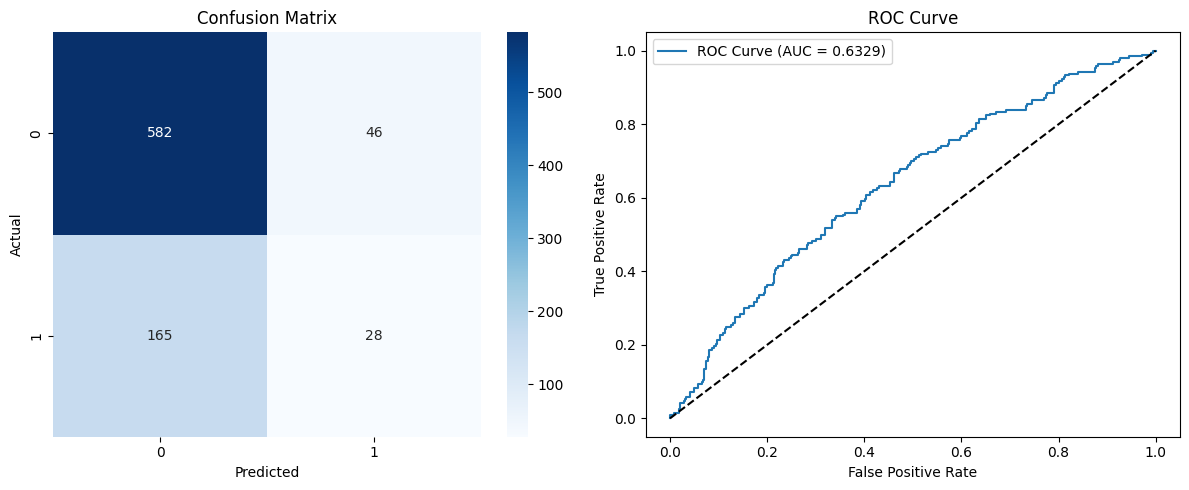

In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train_scaled, y_train)

y_pred = xgb_model.predict(X_test_scaled)
y_pred_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]

# Metrics
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("XGBoost RESULTS")
print(f"F1-Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Visualizations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1)
ax1.set_title('Confusion Matrix')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
ax2.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax2.plot([0,1], [0,1], 'k--')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve')
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
# ========== Import Libraries ==========
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# ========== Prepare Data (Use your existing data) ==========
# Assuming you already have X_train_final, X_test_final, y_train, y_test



# ========== Define Models ==========
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'SVM': SVC(probability=True, random_state=42),
    'Naive Bayes': GaussianNB(),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'XGBoost': xgb.XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1, verbosity=0),
    'LightGBM': lgb.LGBMClassifier(n_estimators=100, random_state=42, verbose=-1, n_jobs=-1)
}

# ========== Train and Evaluate All Models ==========
results = []

print("=" * 80)
print("MODEL COMPARISON - ALL IN ONE")
print("=" * 80)

for name, model in models.items():
    print(f"\nTraining {name}...")

    # Use scaled data for models that need it
    if name in ['Logistic Regression', 'K-Nearest Neighbors', 'SVM', 'Naive Bayes']:
        model.fit(X_train_scaled, y_train)
        train_acc = model.score(X_train_scaled, y_train) * 100
        test_acc = model.score(X_test_scaled, y_test) * 100
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        train_acc = model.score(X_train, y_train) * 100
        test_acc = model.score(X_test, y_test) * 100
        y_pred = model.predict(X_test)

    results.append({
        'Model': name,
        'Train Accuracy (%)': round(train_acc, 2),
        'Test Accuracy (%)': round(test_acc, 2),
        'Predictions': y_pred
    })

    print(f"  ✓ Train Accuracy: {train_acc:.2f}%")
    print(f"  ✓ Test Accuracy:  {test_acc:.2f}%")

# ========== Create Results DataFrame ==========
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Test Accuracy (%)', ascending=False).reset_index(drop=True)

print("\n" + "=" * 80)
print("SUMMARY TABLE")
print("=" * 80)
print(results_df[['Model', 'Train Accuracy (%)', 'Test Accuracy (%)']].to_string(index=False))

# ========== Best Model ==========
best_model_name = results_df.iloc[0]['Model']
best_accuracy = results_df.iloc[0]['Test Accuracy (%)']

print("\n" + "=" * 80)
print(f"🏆 BEST MODEL: {best_model_name}")
print(f"   Test Accuracy: {best_accuracy:.2f}%")
print("=" * 80)

# ========== Detailed Evaluation for Best Model ==========
best_predictions = results_df.iloc[0]['Predictions']

print("\n" + "=" * 80)
print(f"DETAILED EVALUATION - {best_model_name}")
print("=" * 80)

print("\n📊 CONFUSION MATRIX:")
print(confusion_matrix(y_test, best_predictions))

print("\n📋 CLASSIFICATION REPORT:")
print(classification_report(y_test, best_predictions))

MODEL COMPARISON - ALL IN ONE

Training Random Forest...
  ✓ Train Accuracy: 100.00%
  ✓ Test Accuracy:  75.88%

Training Decision Tree...
  ✓ Train Accuracy: 78.68%
  ✓ Test Accuracy:  73.81%

Training AdaBoost...
  ✓ Train Accuracy: 76.58%
  ✓ Test Accuracy:  76.74%

Training Gradient Boosting...
  ✓ Train Accuracy: 80.02%
  ✓ Test Accuracy:  76.25%

Training Logistic Regression...
  ✓ Train Accuracy: 76.37%
  ✓ Test Accuracy:  76.74%

Training SVM...
  ✓ Train Accuracy: 77.56%
  ✓ Test Accuracy:  76.13%

Training Naive Bayes...
  ✓ Train Accuracy: 67.69%
  ✓ Test Accuracy:  67.84%

Training K-Nearest Neighbors...
  ✓ Train Accuracy: 80.18%
  ✓ Test Accuracy:  72.35%

Training XGBoost...
  ✓ Train Accuracy: 98.78%
  ✓ Test Accuracy:  73.20%

Training LightGBM...
  ✓ Train Accuracy: 90.68%
  ✓ Test Accuracy:  74.54%

SUMMARY TABLE
              Model  Train Accuracy (%)  Test Accuracy (%)
Logistic Regression               76.37              76.74
           AdaBoost               76.5

In [ ]:
# ========== Hyperparameter Tuning ==========
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# Define the best model (based on previous results)
# Example: Random Forest with class_weight='balanced'

print("=" * 60)
print("HYPERPARAMETER TUNING")
print("=" * 60)

# Random Forest Parameter Grid
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', 'balanced_subsample']
}

# Use RandomizedSearchCV for faster tuning
rf_grid = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    n_iter=30,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=42
)

rf_grid.fit(X_train_scaled, y_train)

print(f"\nBest Parameters: {rf_grid.best_params_}")
print(f"Best CV F1-Score: {rf_grid.best_score_*100:.2f}%")

# Evaluate on test set
best_rf = rf_grid.best_estimator_
y_pred_tuned = best_rf.predict(X_test_scaled)

print(f"\nTest Accuracy: {accuracy_score(y_test, y_pred_tuned)*100:.2f}%")
print(f"Test F1-Score: {f1_score(y_test, y_pred_tuned, average='weighted')*100:.2f}%")

HYPERPARAMETER TUNING

Best Parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 15, 'class_weight': 'balanced_subsample'}
Best CV F1-Score: 72.47%

Test Accuracy: 73.45%
Test F1-Score: 71.69%


In [ ]:
# ========== Import Libraries ==========
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# ========== Prepare Data (Use your existing data) ==========
# Assuming you already have X_train_final, X_test_final, y_train, y_test

# Scale features for models that need it
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ========== Define Models ==========
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'SVM': SVC(probability=True, random_state=42),
    'Naive Bayes': GaussianNB(),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'XGBoost': xgb.XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1, verbosity=0),
    'LightGBM': lgb.LGBMClassifier(n_estimators=100, random_state=42, verbose=-1, n_jobs=-1)
}

# ========== Train and Evaluate All Models ==========
results = []

print("=" * 80)
print("MODEL COMPARISON - ALL IN ONE")
print("=" * 80)

for name, model in models.items():
    print(f"\nTraining {name}...")

    # Use scaled data for models that need it
    if name in ['Logistic Regression', 'K-Nearest Neighbors', 'SVM', 'Naive Bayes']:
        model.fit(X_train_scaled, y_train)
        train_acc = model.score(X_train_scaled, y_train) * 100
        test_acc = model.score(X_test_scaled, y_test) * 100
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        train_acc = model.score(X_train, y_train) * 100
        test_acc = model.score(X_test, y_test) * 100
        y_pred = model.predict(X_test)

    results.append({
        'Model': name,
        'Train Accuracy (%)': round(train_acc, 2),
        'Test Accuracy (%)': round(test_acc, 2),
        'Predictions': y_pred
    })

    print(f"  ✓ Train Accuracy: {train_acc:.2f}%")
    print(f"  ✓ Test Accuracy:  {test_acc:.2f}%")

# ========== Create Results DataFrame ==========
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Test Accuracy (%)', ascending=False).reset_index(drop=True)

print("\n" + "=" * 80)
print("SUMMARY TABLE")
print("=" * 80)
print(results_df[['Model', 'Train Accuracy (%)', 'Test Accuracy (%)']].to_string(index=False))

# ========== Best Model ==========
best_model_name = results_df.iloc[0]['Model']
best_accuracy = results_df.iloc[0]['Test Accuracy (%)']

print("\n" + "=" * 80)
print(f"🏆 BEST MODEL: {best_model_name}")
print(f"   Test Accuracy: {best_accuracy:.2f}%")
print("=" * 80)

# ========== Detailed Evaluation for Best Model ==========
best_predictions = results_df.iloc[0]['Predictions']

print("\n" + "=" * 80)
print(f"DETAILED EVALUATION - {best_model_name}")
print("=" * 80)

print("\n📊 CONFUSION MATRIX:")
print(confusion_matrix(y_test, best_predictions))

print("\n📋 CLASSIFICATION REPORT:")
print(classification_report(y_test, best_predictions))

MODEL COMPARISON - ALL IN ONE

Training Random Forest...
  ✓ Train Accuracy: 100.00%
  ✓ Test Accuracy:  75.88%

Training Decision Tree...
  ✓ Train Accuracy: 78.68%
  ✓ Test Accuracy:  73.81%

Training AdaBoost...
  ✓ Train Accuracy: 76.58%
  ✓ Test Accuracy:  76.74%

Training Gradient Boosting...
  ✓ Train Accuracy: 80.02%
  ✓ Test Accuracy:  76.25%

Training Logistic Regression...
  ✓ Train Accuracy: 76.37%
  ✓ Test Accuracy:  76.74%

Training SVM...
  ✓ Train Accuracy: 77.56%
  ✓ Test Accuracy:  76.13%

Training Naive Bayes...
  ✓ Train Accuracy: 67.69%
  ✓ Test Accuracy:  67.84%

Training K-Nearest Neighbors...
  ✓ Train Accuracy: 80.18%
  ✓ Test Accuracy:  72.35%

Training XGBoost...
  ✓ Train Accuracy: 98.78%
  ✓ Test Accuracy:  73.20%

Training LightGBM...
  ✓ Train Accuracy: 90.68%
  ✓ Test Accuracy:  74.54%

SUMMARY TABLE
              Model  Train Accuracy (%)  Test Accuracy (%)
Logistic Regression               76.37              76.74
           AdaBoost               76.5

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from sklearn.model_selection import train_test_split
import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# Your models dictionary - READY TO USE!
models_dict = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'SVM': SVC(probability=True, random_state=42),
    'Naive Bayes': GaussianNB(),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'XGBoost': xgb.XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1, verbosity=0),
    'LightGBM': lgb.LGBMClassifier(n_estimators=100, random_state=42, verbose=-1, n_jobs=-1)
}

# Enhanced overfitting check for CLASSIFICATION models
def quick_overfit_check_classification(fitted_models_dict, X_train, X_val, y_train, y_val, y_train_proba=None, y_val_proba=None):
    """
    Overfitting check for classification models using accuracy + optional AUC
    """
    results = []

    for name, model in fitted_models_dict.items():
        # Accuracy scores
        train_pred = model.predict(X_train)
        val_pred = model.predict(X_val)
        train_acc = accuracy_score(y_train, train_pred)
        val_acc = accuracy_score(y_val, val_pred)
        gap = train_acc - val_acc

        # AUC if probability models
        auc_info = ""
        if hasattr(model, "predict_proba"):
            try:
                train_proba = model.predict_proba(X_train)
                val_proba = model.predict_proba(X_val)
                train_auc = roc_auc_score(y_train, train_proba, multi_class='ovr')
                val_auc = roc_auc_score(y_val, val_proba, multi_class='ovr')
                auc_gap = train_auc - val_auc
                auc_info = f" | AUC Gap: {auc_gap:.3f}"
            except:
                pass

        status = "🔴 OVERFITTING!" if gap > 0.08 else "🟢 Good!"
        if 0.03 < gap <= 0.08:
            status = "🟡 Moderate"

        results.append({
            'Model': name,
            'Train Acc': f"{train_acc:.3f}",
            'Val Acc': f"{val_acc:.3f}",
            'Gap': f"{gap:.3f}",
            'Status': status
        })

        print(f"{name:18} | Train: {train_acc:.3f} | Val: {val_acc:.3f} | Gap: {gap:.3f} {status}{auc_info}")

    df = pd.DataFrame(results)
    print("\n" + "="*70)
    print(df.to_string(index=False))
    print("="*70)

    overfit_count = sum(1 for r in results if float(r['Gap']) > 0.08)
    print(f"\n📊 SUMMARY: {overfit_count}/{len(fitted_models_dict)} models are OVERFITTING!")

    return df

# COMPLETE EXAMPLE with sample data
if __name__ == "__main__":
    # Generate sample classification data
    from sklearn.datasets import make_classification
    from sklearn.preprocessing import StandardScaler

    X, y = make_classification(n_samples=2000, n_features=20, n_informative=15,
                              n_redundant=5, n_classes=3, random_state=42)

    # Split and scale
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    print("🔥 TRAINING ALL MODELS...")
    fitted_models = {}

    for name, model in models_dict.items():
        print(f"Training {name}...")
        model.fit(X_train, y_train)
        fitted_models[name] = model

    print("\n" + "="*80)
    print("OVERFITTING CHECK FOR ALL MODELS")
    print("="*80)

    # Check overfitting!
    results_df = quick_overfit_check_classification(fitted_models, X_train, X_val, y_train, y_val)

🔥 TRAINING ALL MODELS...
Training Random Forest...
Training Decision Tree...
Training AdaBoost...
Training Gradient Boosting...
Training Logistic Regression...
Training SVM...
Training Naive Bayes...
Training K-Nearest Neighbors...
Training XGBoost...
Training LightGBM...

OVERFITTING CHECK FOR ALL MODELS
Random Forest      | Train: 1.000 | Val: 0.840 | Gap: 0.160 🔴 OVERFITTING! | AUC Gap: 0.043
Decision Tree      | Train: 0.799 | Val: 0.667 | Gap: 0.133 🔴 OVERFITTING! | AUC Gap: 0.142
AdaBoost           | Train: 0.734 | Val: 0.687 | Gap: 0.047 🟡 Moderate | AUC Gap: 0.036
Gradient Boosting  | Train: 0.969 | Val: 0.802 | Gap: 0.167 🔴 OVERFITTING! | AUC Gap: 0.059
Logistic Regression | Train: 0.706 | Val: 0.717 | Gap: -0.010 🟢 Good! | AUC Gap: -0.008
SVM                | Train: 0.946 | Val: 0.910 | Gap: 0.036 🟡 Moderate | AUC Gap: 0.015
Naive Bayes        | Train: 0.699 | Val: 0.720 | Gap: -0.021 🟢 Good! | AUC Gap: -0.008
K-Nearest Neighbors | Train: 0.937 | Val: 0.872 | Gap: 0.065 🟡 Mod

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
